⚡ Перед началом решения задачи выполните следующую ячейку - в ней скачиваются нужные файлы логов

In [1]:
!wget -O dataset.csv https://raw.githubusercontent.com/Tolstyakoff/Simulative_Stat/refs/heads/main/dataset.csv

--2026-01-26 10:22:12--  https://raw.githubusercontent.com/Tolstyakoff/Simulative_Stat/refs/heads/main/dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 301517 (294K) [text/plain]
Saving to: ‘dataset.csv’

dataset.csv         100%[===================>] 294.45K  --.-KB/s    in 0.1s    

2026-01-26 10:22:13 (2.58 MB/s) - ‘dataset.csv’ saved [301517/301517]



Загружаем данные из csv с детализацией типов данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy import optimize

def comma_to_float(x):
    """Конвертирует строку с запятой в float"""
    try:
        if pd.isna(x) or str(x).strip() == '':
            return None
        # Убираем пробелы и заменяем запятую на точку
        return float(str(x).replace(',', '.'))
    except:
        return None

ecom = pd.read_csv(                 #Парсим данные, сразу в правильные типы
    'dataset.csv',
    sep=';',
    encoding='utf-8',
    parse_dates=['date'],           #Дата парсится отдельно
    dayfirst=True,
    dtype={                         #строки и целые типы
        'customer_id': 'Int64',     #Int64 (с возможностью пропуска данных)
        'age': 'Int64',
        'gender': 'str',
        'region': 'str',
        'traffic_source': 'str',
        'campaign': 'str',
        'pages_visited':'Int64',
        'converted':'Int64',
        'num_items': 'Int64',
        'delivery_time_days': 'Int64',
        'satisfaction': 'Int64'
        },
    converters={                    #десятичные числа, сначала конвртируем "," -> "."
        'purchase_amount': comma_to_float,
        'time_on_site_s': comma_to_float
    }
)

Определить наличие сезонности бизнеса (количество посетителей и покупателей по месяцам). применить метод  ANOVA (для грубой оценки) различий.

Количество посетителей и покупателей по месяцам:
year_month  unique_visitors  buyers  non_buyers  conversion_rate
   2025-01              894     325         569            36.35
   2025-02              764     281         483            36.78
   2025-03              842     316         526            37.53
   2025-04              850     304         546            35.76
   2025-05              866     316         550            36.49
   2025-06              784     278         506            35.46



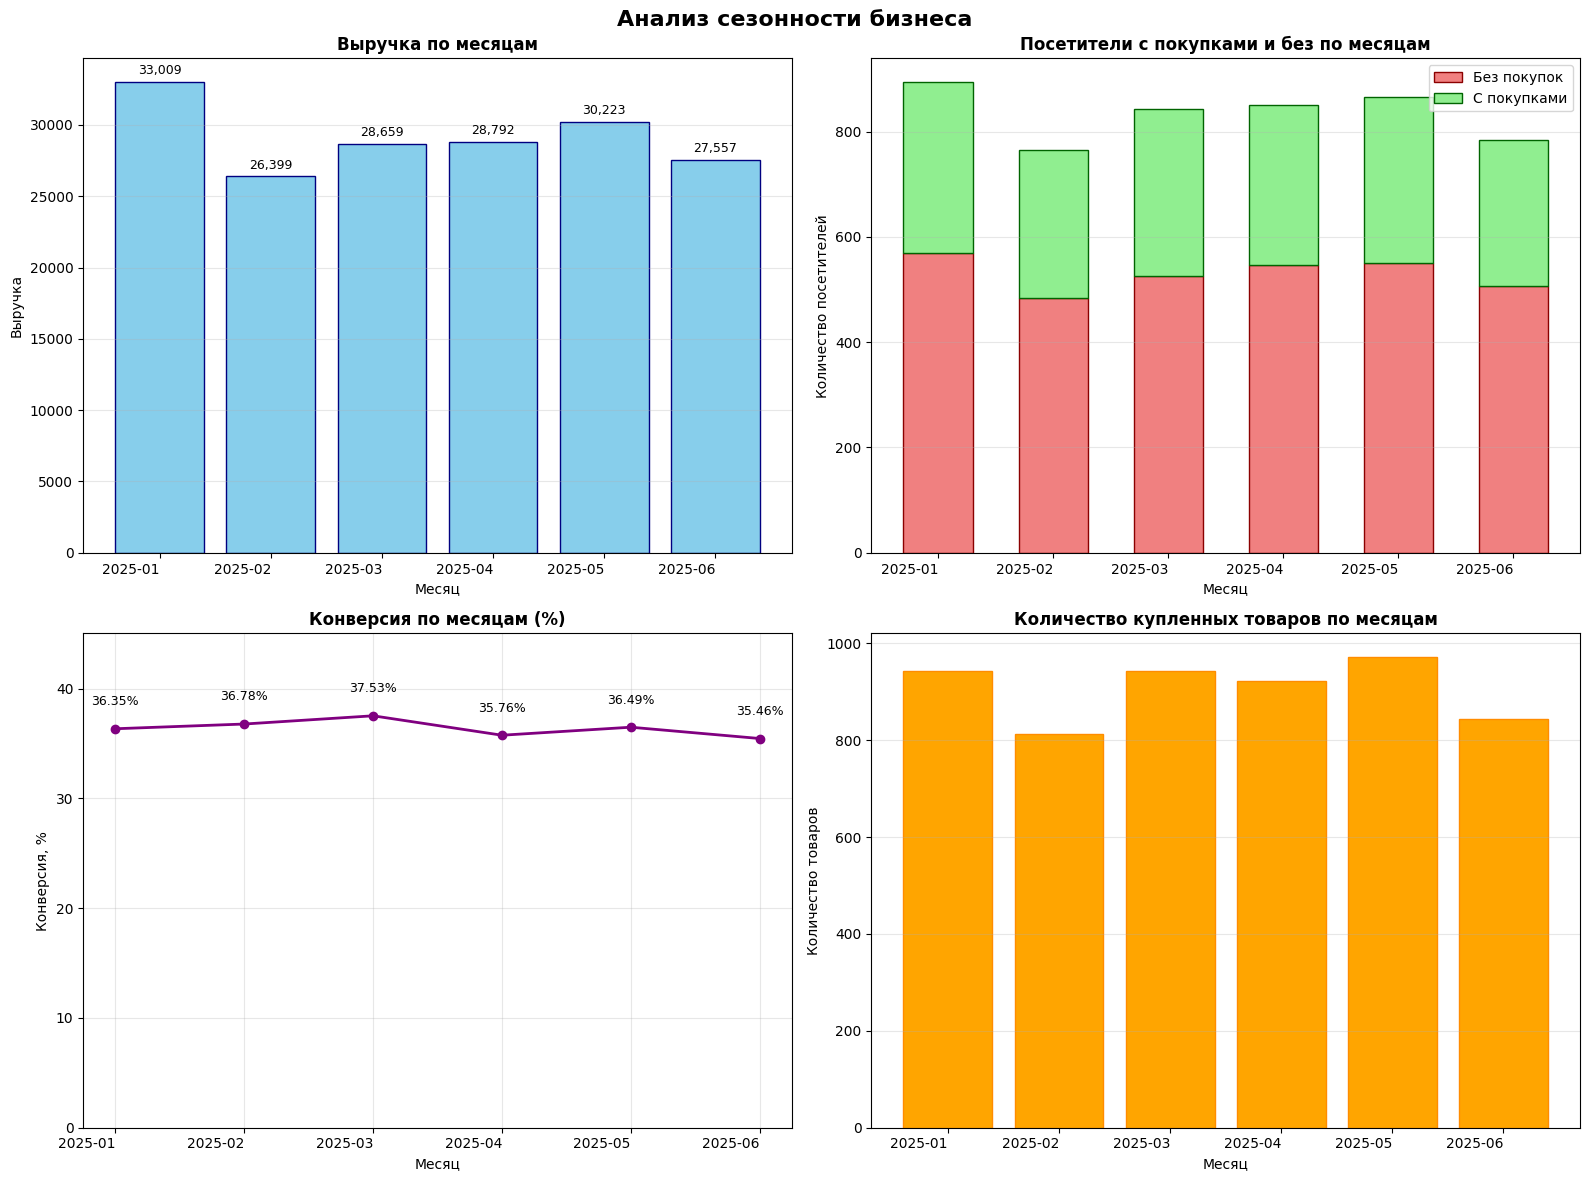


СТАТИСТИЧЕСКИЙ АНАЛИЗ СЕЗОННОСТИ:
ANOVA тест на различия конверсии между месяцами:
  F-статистика: 0.1925
  p-значение: 0.9655
  Вывод: Нет статистически значимых различий между месяцами (p ≥ 0.05)
         Это может указывать на отсутствие выраженной сезонности.

Коэффициент вариации выручки по месяцам: 7.91%
  Низкий коэффициент вариации (<15%) - стабильный бизнес

ИТОГИ ПО СЕЗОННОСТИ:
Всего месяцев в данных: 6
Месяц с максимальной выручкой: 2025-01 (33,009)
Месяц с минимальной выручкой: 2025-02 (26,399)
Месяц с максимальной конверсией: 2025-03 (37.53%)
Средняя месячная конверсия: 36.40%


In [ ]:
# Создаем копию данных для безопасности
df = ecom.copy()

# 1. Преобразуем дату в месяц и год для агрегации
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()  # Первый день месяца как метка
df['year_month'] = df['date'].dt.strftime('%Y-%m')  # Строковое представление

# 2. Анализ сезонности - посетители и покупатели по месяцам
# Считаем уникальных посетителей (customer_id) по месяцам
monthly_visitors = df.groupby('year_month')['customer_id'].nunique().reset_index()
monthly_visitors.columns = ['year_month', 'unique_visitors']

# Считаем покупателей (purchase_amount > 0) по месяцам
monthly_buyers = df[df['purchase_amount'] > 0].groupby('year_month')['customer_id'].nunique().reset_index()
monthly_buyers.columns = ['year_month', 'buyers']

# Объединяем данные
monthly_stats = pd.merge(monthly_visitors, monthly_buyers, on='year_month', how='left')
monthly_stats['buyers'] = monthly_stats['buyers'].fillna(0).astype(int)
monthly_stats['non_buyers'] = monthly_stats['unique_visitors'] - monthly_stats['buyers']
monthly_stats['conversion_rate'] = (monthly_stats['buyers'] / monthly_stats['unique_visitors'] * 100).round(2)

print("Количество посетителей и покупателей по месяцам:")
print(monthly_stats.to_string(index=False))
print("\n" + "="*70)

# 3. Диаграмма с накоплением по месяцам (покупатели vs не покупатели)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ сезонности бизнеса', fontsize=16, fontweight='bold')

# График 1: Суммарная выручка по месяцам
monthly_revenue = df.groupby('year_month')['purchase_amount'].sum().reset_index()
monthly_revenue.columns = ['year_month', 'revenue']

ax1 = axes[0, 0]
ax1.bar(monthly_revenue['year_month'], monthly_revenue['revenue'], color='skyblue', edgecolor='navy')
ax1.set_title('Выручка по месяцам', fontweight='bold')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Выручка')
ax1.set_xticks(range(len(monthly_revenue)))
ax1.set_xticklabels(monthly_revenue['year_month'], rotation=0, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, (_, row) in enumerate(monthly_revenue.iterrows()):
    ax1.text(i, row['revenue'] + max(monthly_revenue['revenue'])*0.01,
             f'{row["revenue"]:,.0f}', ha='center', va='bottom', fontsize=9)

# График 2: Столбчатая диаграмма с накоплением (посетители vs покупатели)
ax2 = axes[0, 1]
bar_width = 0.6
x_pos = np.arange(len(monthly_stats))

bars1 = ax2.bar(x_pos, monthly_stats['non_buyers'], bar_width,
                label='Без покупок', color='lightcoral', edgecolor='darkred')
bars2 = ax2.bar(x_pos, monthly_stats['buyers'], bar_width,
                bottom=monthly_stats['non_buyers'],
                label='С покупками', color='lightgreen', edgecolor='darkgreen')

ax2.set_title('Посетители с покупками и без по месяцам', fontweight='bold')
ax2.set_xlabel('Месяц')
ax2.set_ylabel('Количество посетителей')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(monthly_stats['year_month'], rotation=0, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# График 3: Линейный график конверсии
ax3 = axes[1, 0]
ax3.plot(monthly_stats['year_month'], monthly_stats['conversion_rate'],
         marker='o', linewidth=2, color='purple', markersize=6)
ax3.set_title('Конверсия по месяцам (%)', fontweight='bold')
ax3.set_xlabel('Месяц')
ax3.set_ylabel('Конверсия, %')
ax3.set_xticks(range(len(monthly_stats)))
ax3.set_xticklabels(monthly_stats['year_month'], rotation=0, ha='right')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, max(monthly_stats['conversion_rate']) * 1.2)

# Добавляем значения на точки
for i, (_, row) in enumerate(monthly_stats.iterrows()):
    ax3.text(i, row['conversion_rate'] + max(monthly_stats['conversion_rate'])*0.05,
             f'{row["conversion_rate"]}%', ha='center', va='bottom', fontsize=9)

# График 4: Heatmap сезонности (если данные за несколько лет)
# Преобразуем год и месяц для heatmap
if df['date'].dt.year.nunique() > 1:
    df['year'] = df['date'].dt.year
    df['month_num'] = df['date'].dt.month
    month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                   'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

    # Создаем сводную таблицу по годам и месяцам
    yearly_monthly_revenue = df.groupby(['year', 'month_num'])['purchase_amount'].sum().reset_index()
    pivot_table = yearly_monthly_revenue.pivot(index='month_num', columns='year', values='purchase_amount')
    pivot_table.index = [month_names[i-1] for i in pivot_table.index]

    ax4 = axes[1, 1]
    im = ax4.imshow(pivot_table, cmap='YlOrRd', aspect='auto')
    ax4.set_title('Heatmap выручки по годам и месяцам', fontweight='bold')
    ax4.set_xlabel('Год')
    ax4.set_ylabel('Месяц')

    # Устанавливаем метки
    ax4.set_xticks(range(len(pivot_table.columns)))
    ax4.set_xticklabels(pivot_table.columns.astype(int))
    ax4.set_yticks(range(len(pivot_table.index)))
    ax4.set_yticklabels(pivot_table.index)

    # Добавляем значения в ячейки
    for i in range(len(pivot_table.index)):
        for j in range(len(pivot_table.columns)):
            value = pivot_table.iloc[i, j]
            if not pd.isna(value):
                text_color = 'white' if value > pivot_table.max().max() / 2 else 'black'
                ax4.text(j, i, f'{value:,.0f}', ha='center', va='center',
                        color=text_color, fontsize=8)

    plt.colorbar(im, ax=ax4, label='Выручка')
else:
    # Если данные только за один год, покажем другой график
    ax4 = axes[1, 1]
    monthly_items = df.groupby('year_month')['num_items'].sum().reset_index()
    ax4.bar(monthly_items['year_month'], monthly_items['num_items'], color='orange', edgecolor='darkorange')
    ax4.set_title('Количество купленных товаров по месяцам', fontweight='bold')
    ax4.set_xlabel('Месяц')
    ax4.set_ylabel('Количество товаров')
    ax4.set_xticks(range(len(monthly_items)))
    ax4.set_xticklabels(monthly_items['year_month'], rotation=0, ha='right')
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Статистический анализ сезонности
print("\nСТАТИСТИЧЕСКИЙ АНАЛИЗ СЕЗОННОСТИ:")
print("="*70)

# Проверяем, есть ли значимые различия между месяцами
if len(monthly_stats) > 3:
    # ANOVA для проверки различий в конверсии между месяцами
    # Группируем данные по месяцам
    monthly_groups = []
    months = monthly_stats['year_month'].tolist()

    for month in months:
        month_data = df[df['year_month'] == month]
        if len(month_data) > 0:
            # Берем значения конверсии (0 или 1 для каждой записи)
            converted_vals = month_data['converted'].values
            monthly_groups.append(converted_vals)

    if len(monthly_groups) >= 3:  # Для ANOVA нужно минимум 3 группы
        try:
            f_stat, p_value = stats.f_oneway(*monthly_groups)
            print(f"ANOVA тест на различия конверсии между месяцами:")
            print(f"  F-статистика: {f_stat:.4f}")
            print(f"  p-значение: {p_value:.4f}")
            if p_value < 0.05:
                print("  Вывод: Есть статистически значимые различия между месяцами (p < 0.05)")
                print("         Это указывает на наличие сезонности.")
            else:
                print("  Вывод: Нет статистически значимых различий между месяцами (p ≥ 0.05)")
                print("         Это может указывать на отсутствие выраженной сезонности.")
        except:
            print("  Не удалось выполнить ANOVA тест (проблемы с данными)")

    # Коэффициент вариации для оценки стабильности выручки
    cv_revenue = (monthly_revenue['revenue'].std() / monthly_revenue['revenue'].mean()) * 100
    print(f"\nКоэффициент вариации выручки по месяцам: {cv_revenue:.2f}%")

    if cv_revenue > 30:
        print("  Высокий коэффициент вариации (>30%) - возможна выраженная сезонность")
    elif cv_revenue > 15:
        print("  Средний коэффициент вариации (15-30%) - умеренная сезонность")
    else:
        print("  Низкий коэффициент вариации (<15%) - стабильный бизнес")

# 5. Вывод итоговых данных
print("\n" + "="*70)
print("ИТОГИ ПО СЕЗОННОСТИ:")
print(f"Всего месяцев в данных: {len(monthly_stats)}")
print(f"Месяц с максимальной выручкой: {monthly_revenue.loc[monthly_revenue['revenue'].idxmax(), 'year_month']} ({monthly_revenue['revenue'].max():,.0f})")
print(f"Месяц с минимальной выручкой: {monthly_revenue.loc[monthly_revenue['revenue'].idxmin(), 'year_month']} ({monthly_revenue['revenue'].min():,.0f})")
print(f"Месяц с максимальной конверсией: {monthly_stats.loc[monthly_stats['conversion_rate'].idxmax(), 'year_month']} ({monthly_stats['conversion_rate'].max():.2f}%)")
print(f"Средняя месячная конверсия: {monthly_stats['conversion_rate'].mean():.2f}%")

# Расчет сезонного индекса (если данные за полный год)
if len(monthly_stats) >= 12:
    print("\nСЕЗОННЫЙ ИНДЕКС (среднемесячное значение = 100):")
    seasonal_index = (monthly_revenue['revenue'] / monthly_revenue['revenue'].mean() * 100).round(1)
    for i, (month, index) in enumerate(zip(monthly_revenue['year_month'], seasonal_index)):
        season = ""
        if index > 120:
            season = " (ВЫСОКИЙ сезон)"
        elif index < 80:
            season = " (НИЗКИЙ сезон)"
        print(f"  {month}: {index:.1f}{season}")

Рассчитать по каждой рекламной компании: средний чек, конверсию, применить метод  ANOVA (для грубой оценки)

РАСЧЕТ МЕТРИК ПО РЕКЛАМНЫМ КАМПАНИЯМ


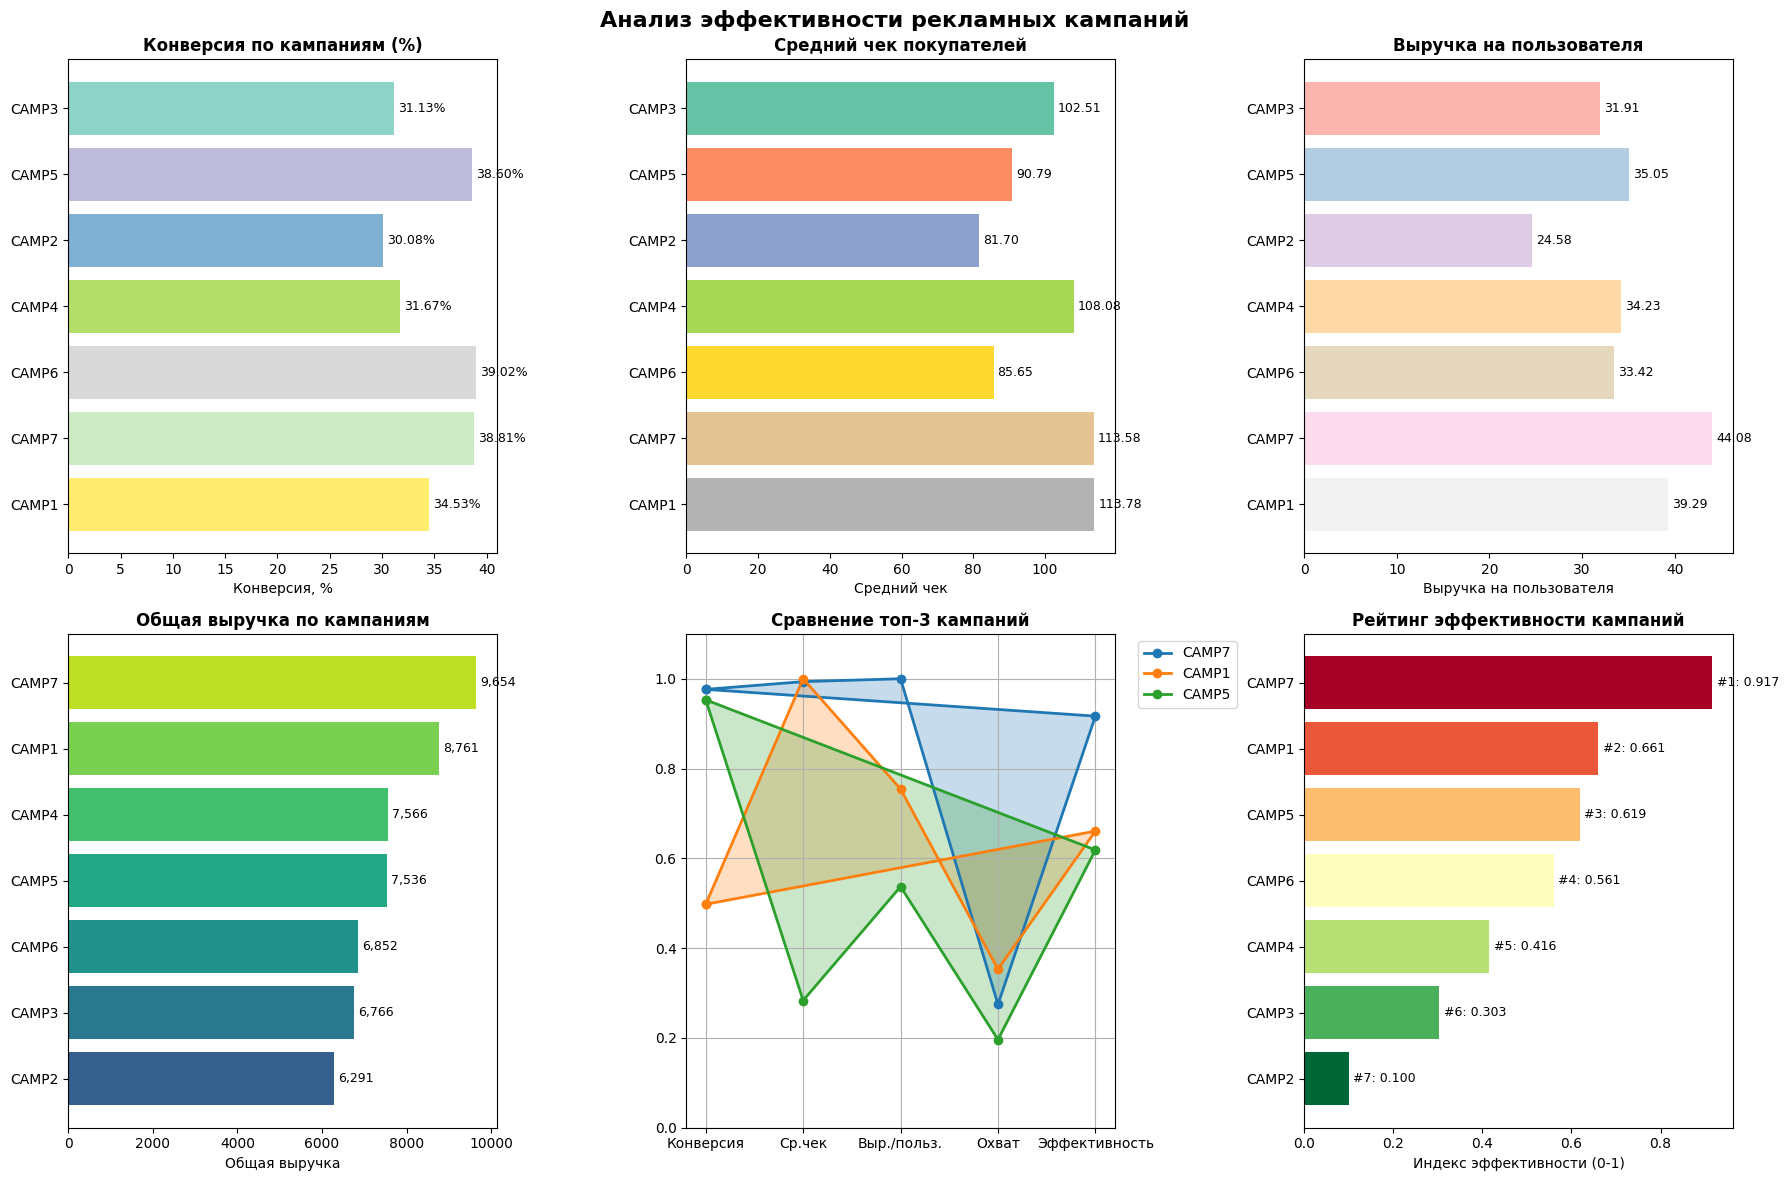


ANOVA АНАЛИЗ ДЛЯ ОЦЕНКИ СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ РАЗЛИЧИЙ
ANOVA для конверсии между кампаниями:
  F-статистика: 1.5481
  p-значение: 1.5880e-01
  Вывод: Нет статистически значимых различий в конверсии между кампаниями (p ≥ 0.05)

--------------------------------------------------
ANOVA для среднего чека покупателей между кампаниями:
  F-статистика: 0.9215
  p-значение: 4.7889e-01
  Вывод: Нет статистически значимых различий в среднем чеке между кампаниями (p ≥ 0.05)

ИТОГОВАЯ ТАБЛИЦА ЭФФЕКТИВНОСТИ РЕКЛАМНЫХ КАМПАНИЙ
 Ранг Кампания  Всего пользователей  Покупатели  Конверсия, %  Ср. чек покупателей  Общая выручка  Cр.чек посетителей  Индекс эффективности
    1    CAMP7                  219          85         38.81               113.58       9,654.04               44.08                  0.92
    2    CAMP1                  223          77         34.53               113.78       8,761.27               39.29                  0.66
    3    CAMP5                  215          83         

In [ ]:
# Создаем копию данных для безопасности
df = ecom.copy()

# Фильтруем только записи с указанной рекламной кампанией
df_campaigns = df[~df['campaign'].isna() & (df['campaign'].str.strip() != '')].copy()

# Проверяем наличие данных
if df_campaigns.empty:
    print("Нет данных по рекламным кампаниям!")
else:
    # 1. Рассчитываем метрики для каждой кампании
    campaign_metrics = {}
    all_campaigns = df_campaigns['campaign'].unique()

    print("РАСЧЕТ МЕТРИК ПО РЕКЛАМНЫМ КАМПАНИЯМ")
    print("="*100)

    for campaign in all_campaigns:
        campaign_data = df_campaigns[df_campaigns['campaign'] == campaign]

        # Общее количество пользователей, видевших кампанию
        total_users = len(campaign_data)

        # Количество покупателей (purchase_amount > 0)
        buyers_data = campaign_data[campaign_data['purchase_amount'] > 0]
        buyers_count = len(buyers_data)

        # Средний чек (включая нулевые продажи)
        avg_check_all = campaign_data['purchase_amount'].mean()

        # Средний чек среди покупателей (только покупки > 0)
        avg_check_buyers = buyers_data['purchase_amount'].mean() if buyers_count > 0 else 0

        # Конверсия (отношение покупателей ко всем пользователям)
        conversion_rate = (buyers_count / total_users * 100) if total_users > 0 else 0

        # Выручка от кампании
        total_revenue = campaign_data['purchase_amount'].sum()

        # ROI (Return on Investment) - упрощенный
        # Предположим, что у нас нет данных о стоимости кампаний, используем отношение выручки к количеству пользователей
        revenue_per_user = total_revenue / total_users if total_users > 0 else 0

        campaign_metrics[campaign] = {
            'total_users': total_users,
            'buyers_count': buyers_count,
            'avg_check_all': avg_check_all,
            'avg_check_buyers': avg_check_buyers,
            'conversion_rate': conversion_rate,
            'total_revenue': total_revenue,
            'revenue_per_user': revenue_per_user
        }

    # Создаем DataFrame с метриками
    metrics_df = pd.DataFrame.from_dict(campaign_metrics, orient='index')
    metrics_df = metrics_df.reset_index().rename(columns={'index': 'campaign'})

    # 2. Ранжируем кампании по эффективности
    # Создаем комплексный индекс эффективности (можно настраивать веса)
    weights = {
        'conversion_rate': 0.4,     # Конверсия - самый важный показатель
        'revenue_per_user': 0.3,    # Средний чек посетитлея (даже если не купил)
        'avg_check_buyers': 0.2,    # Средний чек покупателей
        'total_users': 0.1          # Охват (меньший вес)
    }

    # Нормализуем показатели (min-max scaling)
    def normalize_column(series):
        if series.max() == series.min():
            return pd.Series([0.5] * len(series), index=series.index)
        return (series - series.min()) / (series.max() - series.min())

    normalized_df = metrics_df.copy()
    for col in ['conversion_rate', 'revenue_per_user', 'avg_check_buyers', 'total_users']:
        normalized_df[f'{col}_norm'] = normalize_column(metrics_df[col])

    # Рассчитываем комплексную оценку
    normalized_df['effectiveness_score'] = (
        normalized_df['conversion_rate_norm'] * weights['conversion_rate'] +
        normalized_df['revenue_per_user_norm'] * weights['revenue_per_user'] +
        normalized_df['avg_check_buyers_norm'] * weights['avg_check_buyers'] +
        normalized_df['total_users_norm'] * weights['total_users']
    )

    # Ранжируем по эффективности
    normalized_df = normalized_df.sort_values('effectiveness_score', ascending=False).reset_index(drop=True)
    normalized_df['rank'] = range(1, len(normalized_df) + 1)

    # 3. Визуализация результатов
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Анализ эффективности рекламных кампаний', fontsize=16, fontweight='bold')

    # График 1: Конверсия по кампаниям
    ax1 = axes[0, 0]
    colors1 = plt.cm.Set3(np.linspace(0, 1, len(metrics_df)))
    bars1 = ax1.barh(metrics_df['campaign'], metrics_df['conversion_rate'], color=colors1)
    ax1.set_title('Конверсия по кампаниям (%)', fontweight='bold')
    ax1.set_xlabel('Конверсия, %')
    ax1.invert_yaxis()  # Лучшая кампания сверху

    # Добавляем значения на столбцы
    for bar in bars1:
        width = bar.get_width()
        ax1.text(width + max(metrics_df['conversion_rate'])*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}%', va='center', fontsize=9)

    # График 2: Средний чек покупателей
    ax2 = axes[0, 1]
    colors2 = plt.cm.Set2(np.linspace(0, 1, len(metrics_df)))
    bars2 = ax2.barh(metrics_df['campaign'], metrics_df['avg_check_buyers'], color=colors2)
    ax2.set_title('Средний чек покупателей', fontweight='bold')
    ax2.set_xlabel('Средний чек')
    ax2.invert_yaxis()

    for bar in bars2:
        width = bar.get_width()
        ax2.text(width + max(metrics_df['avg_check_buyers'])*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}', va='center', fontsize=9)

    # График 3: Выручка на пользователя
    ax3 = axes[0, 2]
    colors3 = plt.cm.Pastel1(np.linspace(0, 1, len(metrics_df)))
    bars3 = ax3.barh(metrics_df['campaign'], metrics_df['revenue_per_user'], color=colors3)
    ax3.set_title('Выручка на пользователя', fontweight='bold')
    ax3.set_xlabel('Выручка на пользователя')
    ax3.invert_yaxis()

    for bar in bars3:
        width = bar.get_width()
        ax3.text(width + max(metrics_df['revenue_per_user'])*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}', va='center', fontsize=9)

    # График 4: Общая выручка по кампаниям
    ax4 = axes[1, 0]
    metrics_sorted = metrics_df.sort_values('total_revenue', ascending=True)
    bars4 = ax4.barh(metrics_sorted['campaign'], metrics_sorted['total_revenue'],
                     color=plt.cm.viridis(np.linspace(0.3, 0.9, len(metrics_sorted))))
    ax4.set_title('Общая выручка по кампаниям', fontweight='bold')
    ax4.set_xlabel('Общая выручка')

    for bar in bars4:
        width = bar.get_width()
        ax4.text(width + max(metrics_sorted['total_revenue'])*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:,.0f}', va='center', fontsize=9)

    # График 5: Радарная диаграмма для топ-3 кампаний
    ax5 = axes[1, 1]
    top_n = min(3, len(normalized_df))
    top_campaigns = normalized_df.head(top_n)['campaign'].tolist()

    if top_n >= 2:
        categories = ['Конверсия', 'Ср.чек', 'Выр./польз.', 'Охват', 'Эффективность']

        # Нормализуем показатели для радарной диаграммы (0-1)
        radar_data = []
        for campaign in top_campaigns:
            campaign_data = normalized_df[normalized_df['campaign'] == campaign].iloc[0]
            values = [
                campaign_data['conversion_rate_norm'],
                campaign_data['avg_check_buyers_norm'],
                campaign_data['revenue_per_user_norm'],
                campaign_data['total_users_norm'],
                campaign_data['effectiveness_score']
            ]
            radar_data.append(values)

        angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
        angles += angles[:1]  # Замыкаем круг

        for i, (campaign, values) in enumerate(zip(top_campaigns, radar_data)):
            values += values[:1]  # Замыкаем круг
            ax5.plot(angles, values, 'o-', linewidth=2, label=campaign)
            ax5.fill(angles, values, alpha=0.25)

        ax5.set_xticks(angles[:-1])
        ax5.set_xticklabels(categories, fontsize=10)
        ax5.set_ylim(0, 1.1)
        ax5.set_title(f'Сравнение топ-{top_n} кампаний', fontweight='bold')
        ax5.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        ax5.grid(True)

    # График 6: Рейтинг эффективности
    ax6 = axes[1, 2]
    bars6 = ax6.barh(normalized_df['campaign'], normalized_df['effectiveness_score'],
                     color=plt.cm.RdYlGn(np.linspace(0, 1, len(normalized_df))))
    ax6.set_title('Рейтинг эффективности кампаний', fontweight='bold')
    ax6.set_xlabel('Индекс эффективности (0-1)')
    ax6.invert_yaxis()

    for bar, rank in zip(bars6, normalized_df['rank']):
        width = bar.get_width()
        ax6.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'#{rank}: {width:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # 4. ANOVA анализ для оценки значимости различий
    print("\n" + "="*100)
    print("ANOVA АНАЛИЗ ДЛЯ ОЦЕНКИ СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ РАЗЛИЧИЙ")
    print("="*100)

    # Проводим ANOVA для разных метрик
    anova_results = {}

    # Для конверсии
    conversion_groups = []
    for campaign in all_campaigns:
        campaign_data = df_campaigns[df_campaigns['campaign'] == campaign]
        # Берем бинарный показатель конверсии (0 или 1)
        conversion_groups.append(campaign_data['converted'].values)

    if len(conversion_groups) >= 2:
        try:
            f_stat_conv, p_value_conv = stats.f_oneway(*conversion_groups)
            anova_results['conversion'] = {'F': f_stat_conv, 'p': p_value_conv}

            print(f"ANOVA для конверсии между кампаниями:")
            print(f"  F-статистика: {f_stat_conv:.4f}")
            print(f"  p-значение: {p_value_conv:.4e}")

            if p_value_conv < 0.05:
                print("  Вывод: Есть статистически значимые различия в конверсии между кампаниями (p < 0.05)")

                # Post-hoc тест (Tukey HSD) для определения, какие кампании различаются
                if len(all_campaigns) > 2:
                    print("\n  Post-hoc анализ (Tukey HSD):")
                    # Подготовка данных для Tukey
                    from statsmodels.stats.multicomp import pairwise_tukeyhsd

                    tukey_data = []
                    tukey_labels = []
                    for i, campaign in enumerate(all_campaigns):
                        campaign_data = df_campaigns[df_campaigns['campaign'] == campaign]
                        tukey_data.extend(campaign_data['converted'].values)
                        tukey_labels.extend([campaign] * len(campaign_data))

                    tukey_result = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
                    print(tukey_result)
            else:
                print("  Вывод: Нет статистически значимых различий в конверсии между кампаниями (p ≥ 0.05)")
        except Exception as e:
            print(f"  Ошибка при выполнении ANOVA для конверсии: {e}")

    # Для среднего чека покупателей
    print("\n" + "-"*50)
    purchase_groups = []
    purchase_labels = []

    for campaign in all_campaigns:
        campaign_data = df_campaigns[(df_campaigns['campaign'] == campaign) &
                                    (df_campaigns['purchase_amount'] > 0)]
        if len(campaign_data) >= 3:  # Минимум 3 наблюдения для анализа
            purchase_groups.append(campaign_data['purchase_amount'].values)
            purchase_labels.append(campaign)

    if len(purchase_groups) >= 2:
        try:
            f_stat_purch, p_value_purch = stats.f_oneway(*purchase_groups)
            anova_results['purchase_amount'] = {'F': f_stat_purch, 'p': p_value_purch}

            print(f"ANOVA для среднего чека покупателей между кампаниями:")
            print(f"  F-статистика: {f_stat_purch:.4f}")
            print(f"  p-значение: {p_value_purch:.4e}")

            if p_value_purch < 0.05:
                print("  Вывод: Есть статистически значимые различия в среднем чеке между кампаниями (p < 0.05)")
            else:
                print("  Вывод: Нет статистически значимых различий в среднем чеке между кампаниями (p ≥ 0.05)")
        except Exception as e:
            print(f"  Ошибка при выполнении ANOVA для среднего чека: {e}")

    # 5. Вывод итоговой таблицы с результатами
    print("\n" + "="*100)
    print("ИТОГОВАЯ ТАБЛИЦА ЭФФЕКТИВНОСТИ РЕКЛАМНЫХ КАМПАНИЙ")
    print("="*100)

    # Форматируем вывод
    display_df = normalized_df[['rank', 'campaign', 'total_users', 'buyers_count',
                                'conversion_rate', 'avg_check_buyers',
                                'total_revenue', 'revenue_per_user', 'effectiveness_score']].copy()

    display_df.columns = ['Ранг', 'Кампания', 'Всего пользователей', 'Покупатели',
                         'Конверсия, %', 'Ср. чек покупателей', 'Общая выручка',
                         'Cр.чек посетителей', 'Индекс эффективности']

    # Форматируем числа
    pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if abs(x) >= 0.01 else f'{x:.4f}')

    print(display_df.to_string(index=False))

    # 6. Вывод рекомендаций
    print("\n" + "="*100)
    print("РЕКОМЕНДАЦИИ ПО РЕКЛАМНЫМ КАМПАНИЯМ")
    print("="*100)

    if len(normalized_df) > 0:
        best_campaign = normalized_df.iloc[0]
        worst_campaign = normalized_df.iloc[-1]

        print(f"1. ЛУЧШАЯ КАМПАНИЯ: {best_campaign['campaign']}")
        print(f"   • Конверсия: {best_campaign['conversion_rate']:.2f}%")
        print(f"   • Средний чек покупателей: {best_campaign['avg_check_buyers']:.2f}")
        print(f"   • Выручка на пользователя: {best_campaign['revenue_per_user']:.2f}")
        print(f"   • Рекомендация: Увеличить бюджет, масштабировать подход")

        print(f"\n2. ХУДШАЯ КАМПАНИЯ: {worst_campaign['campaign']}")
        print(f"   • Конверсия: {worst_campaign['conversion_rate']:.2f}%")
        print(f"   • Средний чек покупателей: {worst_campaign['avg_check_buyers']:.2f}")
        print(f"   • Рекомендация: Пересмотреть целевую аудиторию или креатив")

        print(f"\n3. ОБЩИЕ ВЫВОДЫ:")
        print(f"   • Всего проанализировано кампаний: {len(normalized_df)}")
        print(f"   • Средняя конверсия по всем кампаниям: {metrics_df['conversion_rate'].mean():.2f}%")
        print(f"   • Разброс конверсии: {metrics_df['conversion_rate'].min():.2f}% - {metrics_df['conversion_rate'].max():.2f}%")

        # Проверяем результаты ANOVA
        if 'conversion' in anova_results and anova_results['conversion']['p'] < 0.05:
            print(f"   • Статистический анализ: Найдены значимые различия между кампаниями")
            print(f"     Рекомендуется фокусироваться на лучших кампаниях")
        else:
            print(f"   • Статистический анализ: Значимых различий не найдено")
            print(f"     Все кампании работают примерно одинаково эффективно")

        # Дополнительные инсайты
        print(f"\n4. ДОПОЛНИТЕЛЬНЫЕ ИНСАЙТЫ:")

        # Соотношение конверсии и среднего чека
        correlation = metrics_df['conversion_rate'].corr(metrics_df['avg_check_buyers'])
        if abs(correlation) > 0.5:
            direction = "положительной" if correlation > 0 else "отрицательной"
            print(f"   • Обнаружена сильная {direction} корреляция между конверсией и средним чеком")
            print(f"     (коэффициент корреляции: {correlation:.2f})")

        # Анализ размера кампании и эффективности
        size_correlation = metrics_df['total_users'].corr(metrics_df['conversion_rate'])
        if abs(size_correlation) > 0.3:
            trend = "уменьшается" if size_correlation < 0 else "увеличивается"
            print(f"   • С ростом размера кампании конверсия {trend}")
            print(f"     (коэффициент корреляции: {size_correlation:.2f})")

    # 7. Сохранение результатов в CSV
    output_df = display_df.copy()
    output_df.to_csv('campaign_analysis_results.csv', index=False, encoding='utf-8-sig')
    print(f"\nРезультаты сохранены в файл: campaign_analysis_results.csv")

ОЦЕНКА ГЕНДЕРНЫХ РАЗЛИЧИЙ

АНАЛИЗ ПО ВСЕЙ ВЫБОРКЕ

Статистика по всей выборке:
                            Male       Female
count                2440.000000  2440.000000
conversion_rate        36.639344    36.311475
avg_purchase_amount    97.177718    96.042777
avg_time_on_site      362.798607   361.824385
avg_pages_visited       6.007787     5.969672
avg_num_items           2.987696     2.979684
buyers_count          894.000000   886.000000

--------------------------------------------------
Т-ТЕСТЫ (ПО ВСЕЙ ВЫБОРКЕ):
--------------------------------------------------
                metric  statistic  p_value significance
             Конверсия   0.237908 0.811952          н/з
           Средний чек   0.193937 0.846247          н/з
        Время на сайте   0.132940 0.894246          н/з
Просмотренные страницы   0.591210 0.554407          н/з
        Кол-во товаров   0.121342 0.903434          н/з

Примечание: *** - p < 0.001, ** - p < 0.01, * - p < 0.05, н/з - не значимо

ВИЗУАЛИЗАЦ

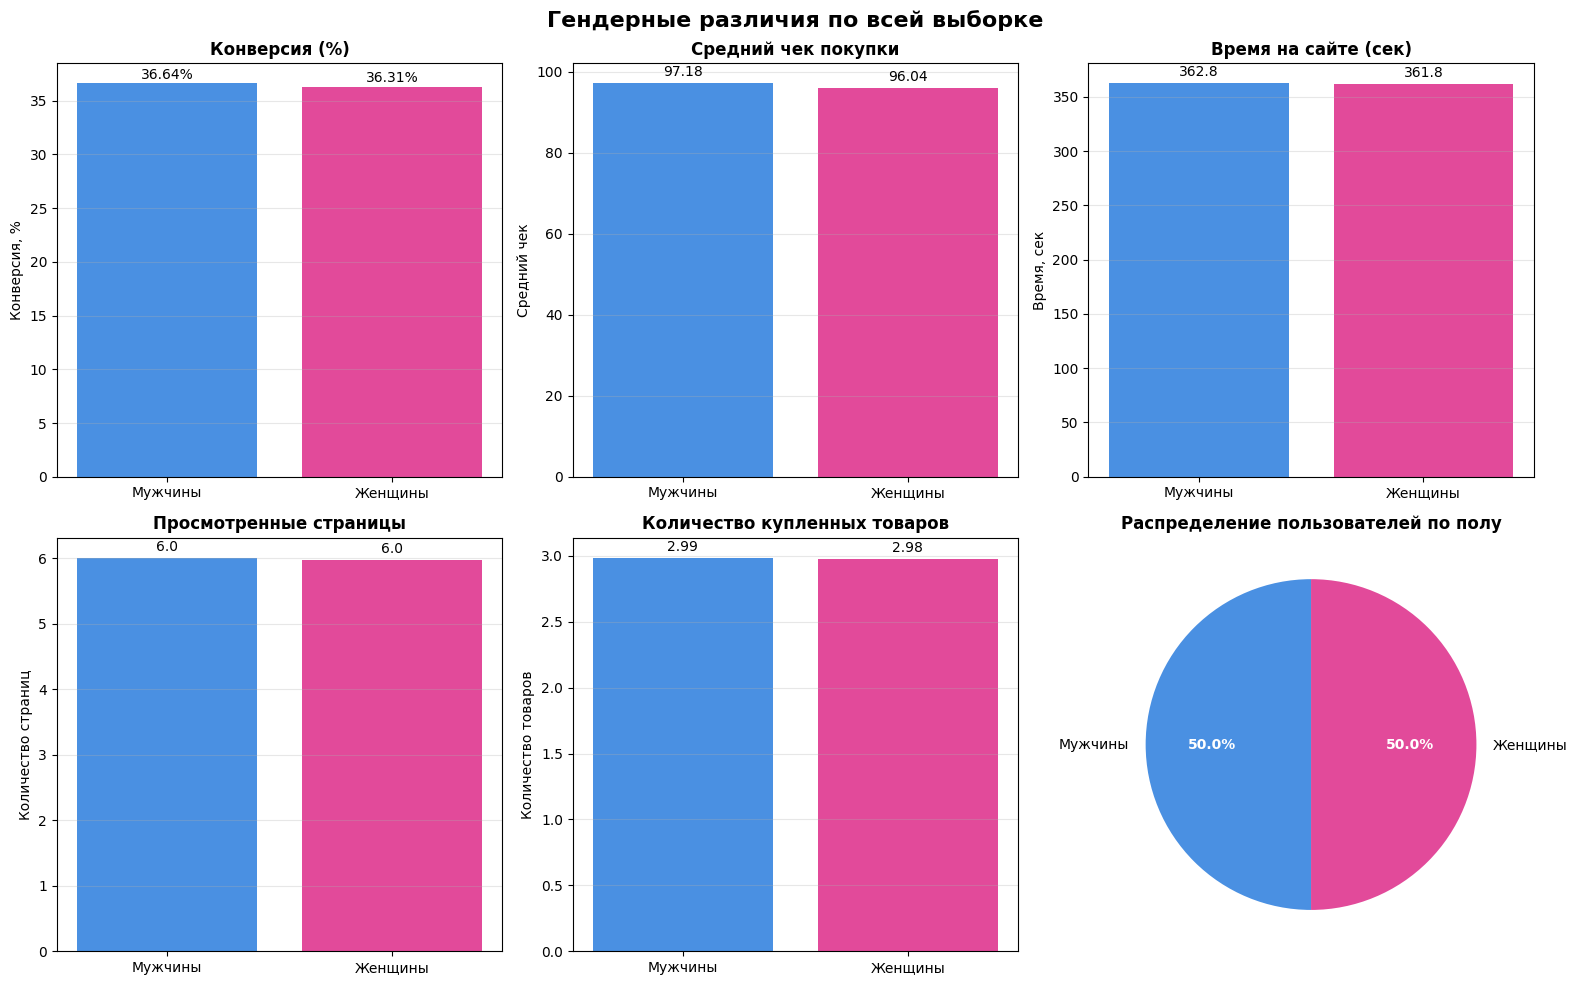


АНАЛИЗ ГЕНДЕРНЫХ РАЗЛИЧИЙ ПО ТОП-3 КАМПАНИЯМ

------------------------------------------------------------
КАМПАНИЯ: CAMP7
------------------------------------------------------------

Статистика для кампании CAMP7:
        count  conversion_rate  avg_purchase_amount  avg_time_on_site  avg_pages_visited  avg_num_items  buyers_count
Male    110.0        43.636364           112.265000        380.740000           6.154545       2.645833          48.0
Female  104.0        32.692308           109.193529        365.397115           6.000000       3.000000          34.0

Т-тесты для кампании CAMP7:
  Конверсия: z=1.646, p=0.0998 (н/з)

------------------------------------------------------------
КАМПАНИЯ: CAMP1
------------------------------------------------------------

Статистика для кампании CAMP1:
        count  conversion_rate  avg_purchase_amount  avg_time_on_site  avg_pages_visited  avg_num_items  buyers_count
Male    109.0        36.697248           111.030750        409.750459     

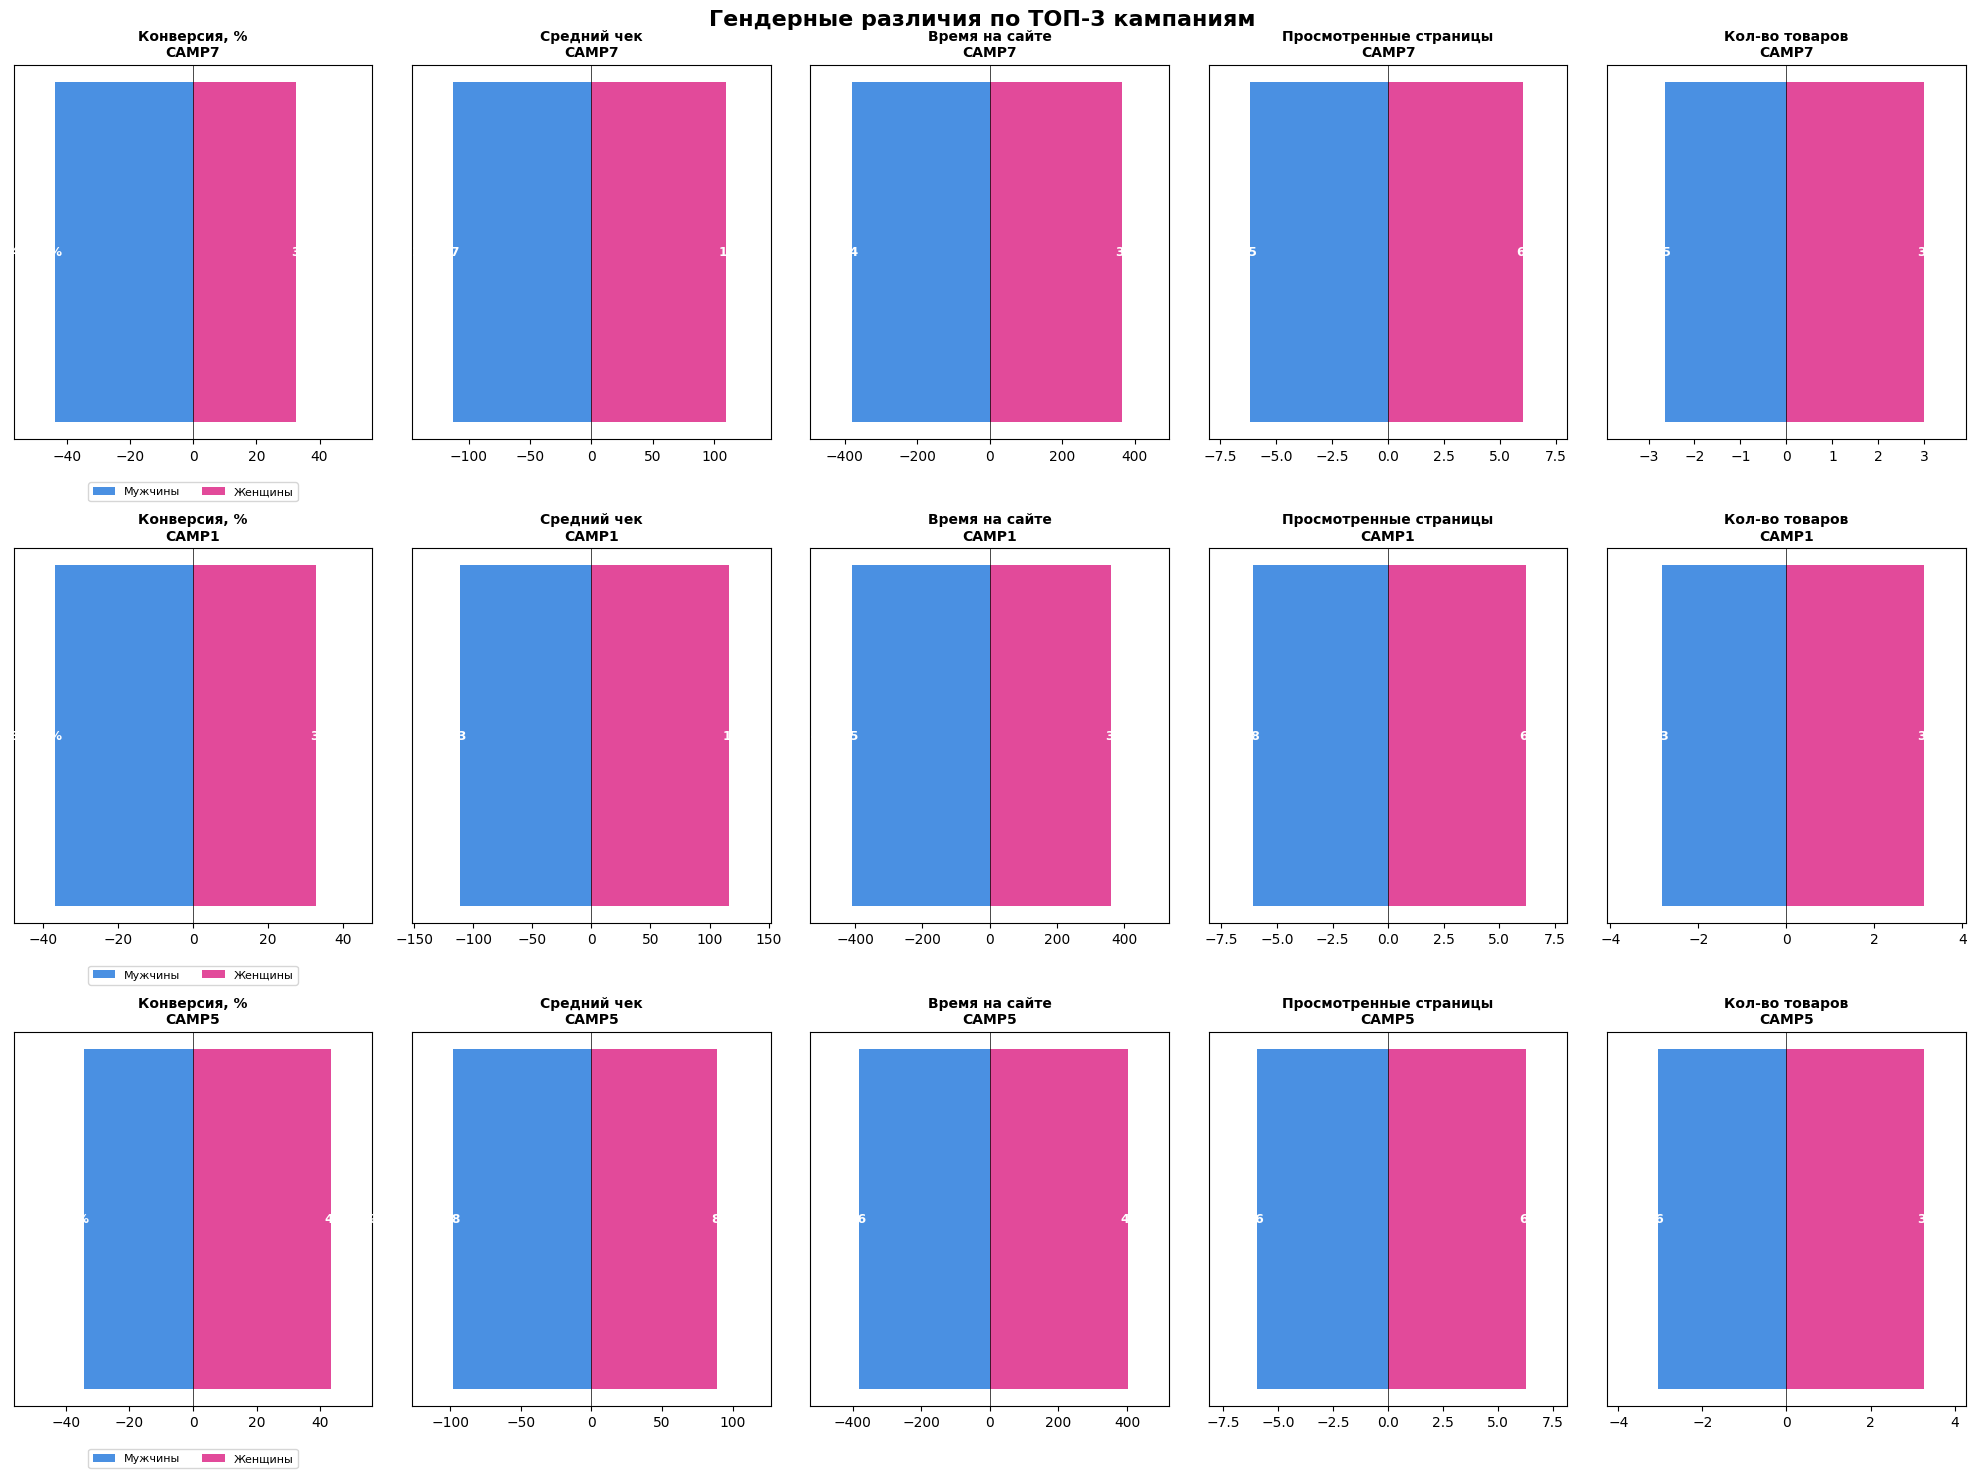


СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГЕНДЕРНЫХ РАЗЛИЧИЙ ПО КАМПАНИЯМ

Разница показателей (Женщины - Мужчины):
campaign  male_users  female_users  conv_diff  purchase_diff  time_diff  pages_diff  items_diff
   CAMP7         110           104 -10.944056      -3.071471 -15.342885   -0.154545    0.354167
   CAMP1         109           113  -3.953885       5.727088 -50.175237    0.120971    0.310135
   CAMP5          99           106   9.052792      -8.465639  22.050648    0.304555    0.223785


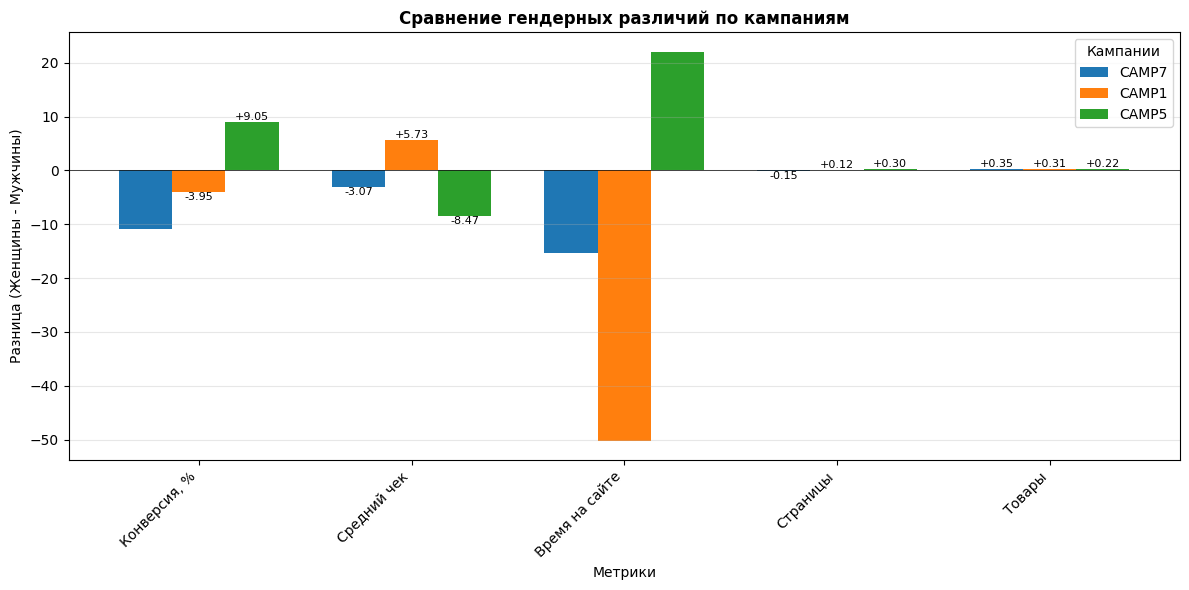


ВЫВОДЫ И РЕКОМЕНДАЦИИ

1. ОБЩИЕ ВЫВОДЫ ПО ВСЕЙ ВЫБОРКЕ:
   • Всего пользователей: 4880
   • Мужчины: 2440.0 (50.0%)
   • Женщины: 2440.0 (50.0%)

2. КЛЮЧЕВЫЕ РАЗЛИЧИЯ:

3. РЕКОМЕНДАЦИИ ПО МАРКЕТИНГУ:
   • Сегментировать рекламные кампании по гендеру
   • Оптимизировать контент и предложения под гендерные предпочтения
   • Провести A/B тестирование для разных гендерных групп

4. РЕКОМЕНДАЦИИ ПО КАМПАНИЯМ:
   • CAMP7: Мужчины конвертируются на 10.9% лучше
   • CAMP5: Женщины конвертируются на 9.1% лучше

Результаты сохранены в файл: gender_analysis_results.csv

АНАЛИЗ ЗАВЕРШЕН


In [5]:
# Исправленная версия кода

# Создаем копию данных для безопасности
df = ecom.copy()

# Фильтруем только записи с указанным гендером
df_gender = df[df['gender'].isin(['Male', 'Female'])].copy()

# Проверяем наличие данных
if df_gender.empty:
    print("Нет данных для анализа гендерных различий!")
else:
    # Определяем ТОП-3 кампании
    top_campaigns = ['CAMP7', 'CAMP1', 'CAMP5']

    print("="*100)
    print("ОЦЕНКА ГЕНДЕРНЫХ РАЗЛИЧИЙ")
    print("="*100)

    # Цветовая гамма
    gender_colors = {
        'Male': '#4A90E2',    # Синий для мужчин
        'Female': '#E24A9A'   # Розовый для женщин
    }

    # 1. АНАЛИЗ ПО ВСЕЙ ВЫБОРКЕ
    print("\n" + "="*100)
    print("АНАЛИЗ ПО ВСЕЙ ВЫБОРКЕ")
    print("="*100)

    # Создаем DataFrame для хранения результатов
    gender_summary = pd.DataFrame()

    # Рассчитываем метрики для каждого гендера
    for gender in ['Male', 'Female']:
        gender_data = df_gender[df_gender['gender'] == gender]
        buyers_data = gender_data[gender_data['purchase_amount'] > 0]

        # Проверяем наличие данных
        total_count = len(gender_data)
        buyers_count = len(buyers_data)

        summary = {
            'count': total_count,
            'conversion_rate': (gender_data['converted'].mean() * 100) if total_count > 0 else 0,
            'avg_purchase_amount': buyers_data['purchase_amount'].mean() if buyers_count > 0 else 0,
            'avg_time_on_site': gender_data['time_on_site_s'].mean() if total_count > 0 else 0,
            'avg_pages_visited': gender_data['pages_visited'].mean() if total_count > 0 else 0,
            'avg_num_items': buyers_data['num_items'].mean() if buyers_count > 0 else 0,
            'buyers_count': buyers_count
        }

        gender_summary[gender] = pd.Series(summary)

    print("\nСтатистика по всей выборке:")
    print(gender_summary.to_string())

    # T-тесты для всей выборки
    print("\n" + "-"*50)
    print("Т-ТЕСТЫ (ПО ВСЕЙ ВЫБОРКЕ):")
    print("-"*50)

    # Импортируем нужные функции
    from statsmodels.stats.proportion import proportions_ztest
    import scipy.stats as scipy_stats

    metrics_tests = []

    # Конверсия (биномиальные данные - используем пропорциональный z-тест)
    male_converted = df_gender[df_gender['gender'] == 'Male']['converted'].sum()
    male_total = len(df_gender[df_gender['gender'] == 'Male'])
    female_converted = df_gender[df_gender['gender'] == 'Female']['converted'].sum()
    female_total = len(df_gender[df_gender['gender'] == 'Female'])

    if male_total > 0 and female_total > 0:
        z_stat, p_value = proportions_ztest([male_converted, female_converted],
                                            [male_total, female_total])
        metrics_tests.append({
            'metric': 'Конверсия',
            'statistic': z_stat,
            'p_value': p_value,
            'significance': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'н/з'
        })
    else:
        print("Предупреждение: Недостаточно данных для теста конверсии")

    # Средний чек покупки (только покупатели)
    male_buyers = df_gender[(df_gender['gender'] == 'Male') & (df_gender['purchase_amount'] > 0)]
    female_buyers = df_gender[(df_gender['gender'] == 'Female') & (df_gender['purchase_amount'] > 0)]

    if len(male_buyers) > 1 and len(female_buyers) > 1:
        t_stat, p_value = scipy_stats.ttest_ind(male_buyers['purchase_amount'],
                                              female_buyers['purchase_amount'],
                                              equal_var=False)
        metrics_tests.append({
            'metric': 'Средний чек',
            'statistic': t_stat,
            'p_value': p_value,
            'significance': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'н/з'
        })
    else:
        print("Предупреждение: Недостаточно данных для теста среднего чека")

    # Время на сайте
    male_time = df_gender[df_gender['gender'] == 'Male']['time_on_site_s'].dropna()
    female_time = df_gender[df_gender['gender'] == 'Female']['time_on_site_s'].dropna()

    if len(male_time) > 1 and len(female_time) > 1:
        t_stat, p_value = scipy_stats.ttest_ind(male_time, female_time, equal_var=False)
        metrics_tests.append({
            'metric': 'Время на сайте',
            'statistic': t_stat,
            'p_value': p_value,
            'significance': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'н/з'
        })
    else:
        print("Предупреждение: Недостаточно данных для теста времени на сайте")

    # Число просмотренных страниц
    male_pages = df_gender[df_gender['gender'] == 'Male']['pages_visited'].dropna()
    female_pages = df_gender[df_gender['gender'] == 'Female']['pages_visited'].dropna()

    if len(male_pages) > 1 and len(female_pages) > 1:
        t_stat, p_value = scipy_stats.ttest_ind(male_pages, female_pages, equal_var=False)
        metrics_tests.append({
            'metric': 'Просмотренные страницы',
            'statistic': t_stat,
            'p_value': p_value,
            'significance': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'н/з'
        })
    else:
        print("Предупреждение: Недостаточно данных для теста просмотренных страниц")

    # Количество купленных товаров (только покупатели)
    if len(male_buyers) > 1 and len(female_buyers) > 1:
        male_items = male_buyers['num_items'].dropna()
        female_items = female_buyers['num_items'].dropna()

        if len(male_items) > 1 and len(female_items) > 1:
            t_stat, p_value = scipy_stats.ttest_ind(male_items, female_items, equal_var=False)
            metrics_tests.append({
                'metric': 'Кол-во товаров',
                'statistic': t_stat,
                'p_value': p_value,
                'significance': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'н/з'
            })
        else:
            print("Предупреждение: Недостаточно данных для теста количества товаров")

    # Выводим результаты t-тестов
    if metrics_tests:
        tests_df = pd.DataFrame(metrics_tests)
        print(tests_df.to_string(index=False))
        print("\nПримечание: *** - p < 0.001, ** - p < 0.01, * - p < 0.05, н/з - не значимо")
    else:
        print("Не удалось выполнить ни одного статистического теста")

    # 2. ВИЗУАЛИЗАЦИЯ ДЛЯ ВСЕЙ ВЫБОРКИ
    print("\n" + "="*100)
    print("ВИЗУАЛИЗАЦИЯ ГЕНДЕРНЫХ РАЗЛИЧИЙ (ВСЯ ВЫБОРКА)")
    print("="*100)

    fig1, axes1 = plt.subplots(2, 3, figsize=(16, 10))
    fig1.suptitle('Гендерные различия по всей выборке', fontsize=16, fontweight='bold')

    # График 1: Конверсия
    ax1 = axes1[0, 0]
    conversion_data = [gender_summary.loc['conversion_rate', 'Male'],
                       gender_summary.loc['conversion_rate', 'Female']]

    # Проверяем на NaN
    if not any(pd.isna(conversion_data)):
        bars1 = ax1.bar(['Мужчины', 'Женщины'], conversion_data,
                        color=[gender_colors['Male'], gender_colors['Female']])
        ax1.set_title('Конверсия (%)', fontweight='bold')
        ax1.set_ylabel('Конверсия, %')
        ax1.grid(axis='y', alpha=0.3)

        # Добавляем значения на столбцы
        for bar, value in zip(bars1, conversion_data):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{value:.2f}%', ha='center', va='bottom')
    else:
        ax1.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)
        ax1.set_title('Конверсия (%)', fontweight='bold')

    # График 2: Средний чек покупки
    ax2 = axes1[0, 1]
    purchase_data = [gender_summary.loc['avg_purchase_amount', 'Male'],
                     gender_summary.loc['avg_purchase_amount', 'Female']]

    if not any(pd.isna(purchase_data)):
        bars2 = ax2.bar(['Мужчины', 'Женщины'], purchase_data,
                        color=[gender_colors['Male'], gender_colors['Female']])
        ax2.set_title('Средний чек покупки', fontweight='bold')
        ax2.set_ylabel('Средний чек')
        ax2.grid(axis='y', alpha=0.3)

        for bar, value in zip(bars2, purchase_data):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + max(purchase_data)*0.01,
                    f'{value:.2f}', ha='center', va='bottom')
    else:
        ax2.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)
        ax2.set_title('Средний чек покупки', fontweight='bold')

    # График 3: Время на сайте
    ax3 = axes1[0, 2]
    time_data = [gender_summary.loc['avg_time_on_site', 'Male'],
                 gender_summary.loc['avg_time_on_site', 'Female']]

    if not any(pd.isna(time_data)):
        bars3 = ax3.bar(['Мужчины', 'Женщины'], time_data,
                        color=[gender_colors['Male'], gender_colors['Female']])
        ax3.set_title('Время на сайте (сек)', fontweight='bold')
        ax3.set_ylabel('Время, сек')
        ax3.grid(axis='y', alpha=0.3)

        for bar, value in zip(bars3, time_data):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + max(time_data)*0.01,
                    f'{value:.1f}', ha='center', va='bottom')
    else:
        ax3.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)
        ax3.set_title('Время на сайте (сек)', fontweight='bold')

    # График 4: Просмотренные страницы
    ax4 = axes1[1, 0]
    pages_data = [gender_summary.loc['avg_pages_visited', 'Male'],
                  gender_summary.loc['avg_pages_visited', 'Female']]

    if not any(pd.isna(pages_data)):
        bars4 = ax4.bar(['Мужчины', 'Женщины'], pages_data,
                        color=[gender_colors['Male'], gender_colors['Female']])
        ax4.set_title('Просмотренные страницы', fontweight='bold')
        ax4.set_ylabel('Количество страниц')
        ax4.grid(axis='y', alpha=0.3)

        for bar, value in zip(bars4, pages_data):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + max(pages_data)*0.01,
                    f'{value:.1f}', ha='center', va='bottom')
    else:
        ax4.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)
        ax4.set_title('Просмотренные страницы', fontweight='bold')

    # График 5: Количество купленных товаров
    ax5 = axes1[1, 1]
    items_data = [gender_summary.loc['avg_num_items', 'Male'],
                  gender_summary.loc['avg_num_items', 'Female']]

    if not any(pd.isna(items_data)):
        bars5 = ax5.bar(['Мужчины', 'Женщины'], items_data,
                        color=[gender_colors['Male'], gender_colors['Female']])
        ax5.set_title('Количество купленных товаров', fontweight='bold')
        ax5.set_ylabel('Количество товаров')
        ax5.grid(axis='y', alpha=0.3)

        for bar, value in zip(bars5, items_data):
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height + max(items_data)*0.01,
                    f'{value:.2f}', ha='center', va='bottom')
    else:
        ax5.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)
        ax5.set_title('Количество купленных товаров', fontweight='bold')

    # График 6: Распределение по полу
    ax6 = axes1[1, 2]
    gender_counts = [gender_summary.loc['count', 'Male'], gender_summary.loc['count', 'Female']]

    # Проверяем на NaN и нулевые значения
    if not any(pd.isna(gender_counts)) and sum(gender_counts) > 0:
        colors_pie = [gender_colors['Male'], gender_colors['Female']]
        labels_pie = ['Мужчины', 'Женщины']

        # Рассчитываем проценты вручную для проверки
        total = sum(gender_counts)
        percentages = [count/total*100 for count in gender_counts]

        # Проверяем, что проценты корректны
        if all(p >= 0 for p in percentages):
            wedges, texts, autotexts = ax6.pie(gender_counts, labels=labels_pie, colors=colors_pie,
                                              autopct='%1.1f%%', startangle=90)
            ax6.set_title('Распределение пользователей по полу', fontweight='bold')

            # Настраиваем отображение процентов
            for autotext in autotexts:
                autotext.set_color('white')
                autotext.set_fontweight('bold')
        else:
            ax6.text(0.5, 0.5, 'Некорректные данные', ha='center', va='center', fontsize=12)
            ax6.set_title('Распределение пользователей по полу', fontweight='bold')
    else:
        ax6.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)
        ax6.set_title('Распределение пользователей по полу', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 3. АНАЛИЗ ПО ТОП-3 КАМПАНИЯМ
    print("\n" + "="*100)
    print("АНАЛИЗ ГЕНДЕРНЫХ РАЗЛИЧИЙ ПО ТОП-3 КАМПАНИЯМ")
    print("="*100)

    # Создаем словарь для хранения результатов по кампаниям
    campaign_gender_results = {}

    # Диаграммы для каждой кампании
    fig2, axes2 = plt.subplots(3, 5, figsize=(20, 15))
    fig2.suptitle('Гендерные различия по ТОП-3 кампаниям', fontsize=16, fontweight='bold')

    for idx, campaign in enumerate(top_campaigns):
        campaign_data = df_gender[df_gender['campaign'] == campaign]

        if len(campaign_data) == 0:
            print(f"\nКампания {campaign}: нет данных")

            # Заполняем пустыми графиками
            for col_idx in range(5):
                ax = axes2[idx, col_idx]
                ax.text(0.5, 0.5, f'Нет данных\n{campaign}',
                       ha='center', va='center', fontsize=10)
                ax.set_title(f'Кампания {campaign}', fontweight='bold')
                ax.set_xticks([])
                ax.set_yticks([])
            continue

        print(f"\n{'-'*60}")
        print(f"КАМПАНИЯ: {campaign}")
        print(f"{'-'*60}")

        # Рассчитываем метрики для кампании
        campaign_summary = {}
        for gender in ['Male', 'Female']:
            gender_data = campaign_data[campaign_data['gender'] == gender]
            buyers_data = gender_data[gender_data['purchase_amount'] > 0]

            total_count = len(gender_data)
            buyers_count = len(buyers_data)

            summary = {
                'count': total_count,
                'conversion_rate': (gender_data['converted'].mean() * 100) if total_count > 0 else 0,
                'avg_purchase_amount': buyers_data['purchase_amount'].mean() if buyers_count > 0 else 0,
                'avg_time_on_site': gender_data['time_on_site_s'].mean() if total_count > 0 else 0,
                'avg_pages_visited': gender_data['pages_visited'].mean() if total_count > 0 else 0,
                'avg_num_items': buyers_data['num_items'].mean() if buyers_count > 0 else 0,
                'buyers_count': buyers_count
            }

            campaign_summary[gender] = summary

        campaign_gender_results[campaign] = campaign_summary

        # Выводим статистику
        summary_df = pd.DataFrame(campaign_summary).T
        print(f"\nСтатистика для кампании {campaign}:")
        print(summary_df.to_string())

        # T-тесты для кампании
        print(f"\nТ-тесты для кампании {campaign}:")

        # Конверсия
        male_conv = campaign_data[campaign_data['gender'] == 'Male']['converted'].sum()
        male_total = len(campaign_data[campaign_data['gender'] == 'Male'])
        female_conv = campaign_data[campaign_data['gender'] == 'Female']['converted'].sum()
        female_total = len(campaign_data[campaign_data['gender'] == 'Female'])

        if male_total > 0 and female_total > 0:
            z_stat, p_value = proportions_ztest([male_conv, female_conv],
                                              [male_total, female_total])
            print(f"  Конверсия: z={z_stat:.3f}, p={p_value:.4f}",
                  "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "(н/з)")

        # Построение диаграмм Торнадо для каждой метрики
        metrics_to_plot = [
            ('conversion_rate', 'Конверсия, %', 0),
            ('avg_purchase_amount', 'Средний чек', 1),
            ('avg_time_on_site', 'Время на сайте', 2),
            ('avg_pages_visited', 'Просмотренные страницы', 3),
            ('avg_num_items', 'Кол-во товаров', 4)
        ]

        for metric, title, col_idx in metrics_to_plot:
            ax = axes2[idx, col_idx]

            # Получаем данные
            male_value = campaign_summary['Male'][metric]
            female_value = campaign_summary['Female'][metric]

            # Проверяем на NaN
            if pd.isna(male_value) or pd.isna(female_value):
                ax.text(0.5, 0.5, 'Нет данных',
                       ha='center', va='center', fontsize=9)
                ax.set_title(f'{title}\n{campaign}', fontweight='bold', fontsize=10)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            # Создаем торнадо-диаграмму
            y_pos = [0]

            # Мужчины влево (отрицательные значения)
            ax.barh(y_pos, [-male_value], height=0.6, color=gender_colors['Male'],
                    label='Мужчины' if col_idx == 0 else "")

            # Женщины вправо (положительные значения)
            ax.barh(y_pos, [female_value], height=0.6, color=gender_colors['Female'],
                    label='Женщины' if col_idx == 0 else "")

            # Настройки графика
            ax.set_title(f'{title}\n{campaign}', fontweight='bold', fontsize=10)
            ax.set_yticks([])

            # Добавляем подписи значений
            ax.text(-male_value*0.95, 0, f'{male_value:.2f}' if metric != 'conversion_rate' else f'{male_value:.2f}%',
                    va='center', ha='right', color='white', fontweight='bold', fontsize=9)
            ax.text(female_value*0.95, 0, f'{female_value:.2f}' if metric != 'conversion_rate' else f'{female_value:.2f}%',
                    va='center', ha='left', color='white', fontweight='bold', fontsize=9)

            # Настройка осей для лучшей читаемости
            max_val = max(abs(male_value), abs(female_value))
            if max_val > 0:
                ax.set_xlim(-max_val*1.3, max_val*1.3)
            else:
                ax.set_xlim(-1, 1)

            # Добавляем вертикальную линию в центре
            ax.axvline(x=0, color='black', linewidth=0.5)

            # Добавляем легенду только для первого столбца
            if col_idx == 0:
                ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=8)

    plt.tight_layout()
    plt.show()

    # 4. СРАВНИТЕЛЬНЫЙ АНАЛИЗ ПО КАМПАНИЯМ
    print("\n" + "="*100)
    print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГЕНДЕРНЫХ РАЗЛИЧИЙ ПО КАМПАНИЯМ")
    print("="*100)

    # Создаем сводную таблицу
    comparison_data = []

    for campaign in top_campaigns:
        if campaign in campaign_gender_results:
            results = campaign_gender_results[campaign]

            # Рассчитываем разницу (женщины - мужчины)
            diff_data = {
                'campaign': campaign,
                'male_users': results['Male']['count'],
                'female_users': results['Female']['count'],
                'conv_diff': results['Female']['conversion_rate'] - results['Male']['conversion_rate'],
                'purchase_diff': results['Female']['avg_purchase_amount'] - results['Male']['avg_purchase_amount'],
                'time_diff': results['Female']['avg_time_on_site'] - results['Male']['avg_time_on_site'],
                'pages_diff': results['Female']['avg_pages_visited'] - results['Male']['avg_pages_visited'],
                'items_diff': results['Female']['avg_num_items'] - results['Male']['avg_num_items']
            }

            comparison_data.append(diff_data)

    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)

        print("\nРазница показателей (Женщины - Мужчины):")
        print(comparison_df.to_string(index=False))

        # Визуализация сравнения
        fig3, ax3 = plt.subplots(figsize=(12, 6))

        metrics_comparison = ['conv_diff', 'purchase_diff', 'time_diff', 'pages_diff', 'items_diff']
        metric_labels = ['Конверсия, %', 'Средний чек', 'Время на сайте', 'Страницы', 'Товары']

        # Фильтруем данные с NaN
        valid_metrics = []
        valid_labels = []

        for metric, label in zip(metrics_comparison, metric_labels):
            if not comparison_df[metric].isna().all():
                valid_metrics.append(metric)
                valid_labels.append(label)

        if valid_metrics:
            x = np.arange(len(valid_metrics))
            width = 0.25

            for i, campaign in enumerate(comparison_df['campaign']):
                values = comparison_df[comparison_df['campaign'] == campaign][valid_metrics].values[0]
                offset = (i - 1) * width
                bars = ax3.bar(x + offset, values, width, label=campaign)

                # Добавляем значения на столбцы
                for bar, value in zip(bars, values):
                    if not pd.isna(value):
                        height = bar.get_height()
                        va = 'bottom' if height >= 0 else 'top'
                        color = 'black' if abs(height) < max(abs(values)) * 0.5 else 'white'
                        ax3.text(bar.get_x() + bar.get_width()/2.,
                                height + (0.01 if height >= 0 else -0.01),
                                f'{value:+.2f}' if label != 'Конверсия, %' else f'{value:+.2f}%',
                                ha='center', va=va, fontsize=8, color=color)

            ax3.set_xlabel('Метрики')
            ax3.set_ylabel('Разница (Женщины - Мужчины)')
            ax3.set_title('Сравнение гендерных различий по кампаниям', fontweight='bold')
            ax3.set_xticks(x)
            ax3.set_xticklabels(valid_labels, rotation=45, ha='right')
            ax3.axhline(y=0, color='black', linewidth=0.5)
            ax3.legend(title='Кампании')
            ax3.grid(axis='y', alpha=0.3)

            plt.tight_layout()
            plt.show()
        else:
            print("Нет данных для визуализации сравнения")

    # 5. ВЫВОДЫ И РЕКОМЕНДАЦИИ
    print("\n" + "="*100)
    print("ВЫВОДЫ И РЕКОМЕНДАЦИИ")
    print("="*100)

    print("\n1. ОБЩИЕ ВЫВОДЫ ПО ВСЕЙ ВЫБОРКЕ:")
    print(f"   • Всего пользователей: {len(df_gender)}")

    male_count = gender_summary.loc['count', 'Male']
    female_count = gender_summary.loc['count', 'Female']
    total_count = male_count + female_count

    if total_count > 0:
        print(f"   • Мужчины: {male_count} ({male_count/total_count*100:.1f}%)")
        print(f"   • Женщины: {female_count} ({female_count/total_count*100:.1f}%)")
    else:
        print("   • Нет данных по распределению пользователей")

    if metrics_tests:
        print("\n2. КЛЮЧЕВЫЕ РАЗЛИЧИЯ:")
        for _, row in tests_df.iterrows():
            if row['significance'] != 'н/з':
                print(f"   • {row['metric']}: статистически значимое различие ({row['significance']})")
                print(f"     t/z-статистика: {row['statistic']:.3f}, p-value: {row['p_value']:.4f}")

    print("\n3. РЕКОМЕНДАЦИИ ПО МАРКЕТИНГУ:")
    print("   • Сегментировать рекламные кампании по гендеру")
    print("   • Оптимизировать контент и предложения под гендерные предпочтения")
    print("   • Провести A/B тестирование для разных гендерных групп")

    print("\n4. РЕКОМЕНДАЦИИ ПО КАМПАНИЯМ:")
    for campaign in top_campaigns:
        if campaign in campaign_gender_results:
            results = campaign_gender_results[campaign]
            male_conv = results['Male']['conversion_rate']
            female_conv = results['Female']['conversion_rate']

            if abs(male_conv - female_conv) > 5:  # Разница более 5%
                better_gender = "Мужчины" if male_conv > female_conv else "Женщины"
                diff = abs(male_conv - female_conv)
                print(f"   • {campaign}: {better_gender} конвертируются на {diff:.1f}% лучше")

    # 6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
    output_data = []

    # Добавляем данные по всей выборке
    for gender in ['Male', 'Female']:
        output_data.append({
            'segment': 'Вся выборка',
            'campaign': 'ALL',
            'gender': 'Мужчины' if gender == 'Male' else 'Женщины',
            'count': gender_summary.loc['count', gender],
            'conversion_rate': gender_summary.loc['conversion_rate', gender],
            'avg_purchase_amount': gender_summary.loc['avg_purchase_amount', gender],
            'avg_time_on_site': gender_summary.loc['avg_time_on_site', gender],
            'avg_pages_visited': gender_summary.loc['avg_pages_visited', gender],
            'avg_num_items': gender_summary.loc['avg_num_items', gender]
        })

    # Добавляем данные по кампаниям
    for campaign in top_campaigns:
        if campaign in campaign_gender_results:
            for gender in ['Male', 'Female']:
                results = campaign_gender_results[campaign][gender]
                output_data.append({
                    'segment': 'По кампании',
                    'campaign': campaign,
                    'gender': 'Мужчины' if gender == 'Male' else 'Женщины',
                    'count': results['count'],
                    'conversion_rate': results['conversion_rate'],
                    'avg_purchase_amount': results['avg_purchase_amount'],
                    'avg_time_on_site': results['avg_time_on_site'],
                    'avg_pages_visited': results['avg_pages_visited'],
                    'avg_num_items': results['avg_num_items']
                })

    output_df = pd.DataFrame(output_data)
    output_df.to_csv('gender_analysis_results.csv', index=False, encoding='utf-8-sig')
    print(f"\nРезультаты сохранены в файл: gender_analysis_results.csv")

print("\n" + "="*100)
print("АНАЛИЗ ЗАВЕРШЕН")
print("="*100)

РАСЧЕТ МЕТРИК ПО ИСТОЧНИКАМ ТРАФИКА


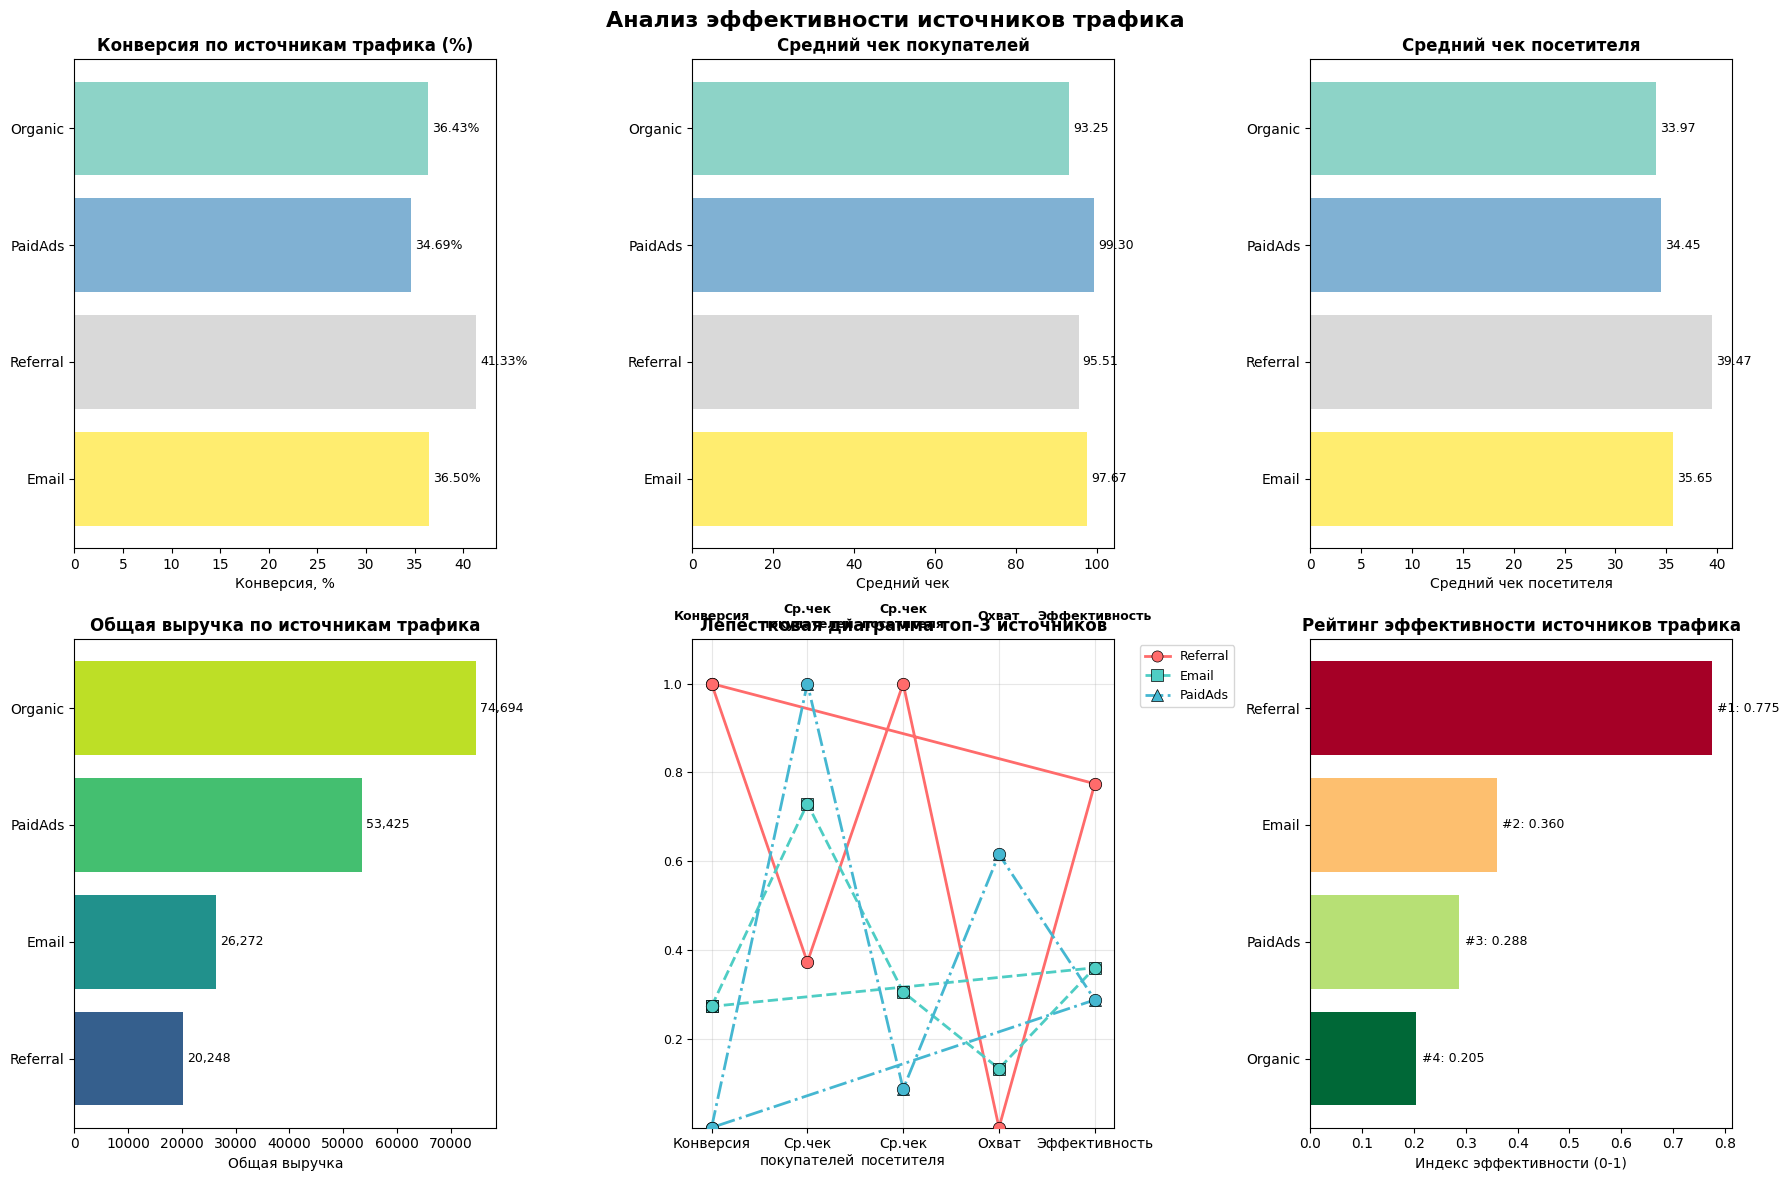


ANOVA АНАЛИЗ ДЛЯ ОЦЕНКИ СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ РАЗЛИЧИЙ
ANOVA для конверсии между источниками трафика:
  F-статистика: 2.4500
  p-значение: 6.1668e-02
  Вывод: Нет статистически значимых различий в конверсии между источниками трафика (p ≥ 0.05)

--------------------------------------------------

ANOVA для среднего чека покупателей между источниками трафика:
  F-статистика: 0.2810
  p-значение: 8.3913e-01
  Вывод: Нет статистически значимых различий в среднем чеке между источниками трафика (p ≥ 0.05)

--------------------------------------------------

ANOVA для среднего чека (включая нулевые продажи) между источниками трафика:
  F-статистика: 0.5842
  p-значение: 6.2531e-01
  Вывод: Нет статистически значимых различий в среднем чеке (включая нулевые) между источниками трафика (p ≥ 0.05)

ИТОГОВАЯ ТАБЛИЦА ЭФФЕКТИВНОСТИ ИСТОЧНИКОВ ТРАФИКА
+--------+--------------------+-----------------+--------------+----------------+----------+---------------+-----------+--------------+-----------

In [6]:
# Создаем копию данных для безопасности
df = ecom.copy()

# Фильтруем только записи с указанным источником трафика
df_traffic = df[~df['traffic_source'].isna() & (df['traffic_source'].str.strip() != '')].copy()

# Проверяем наличие данных
if df_traffic.empty:
    print("Нет данных по источникам трафика!")
else:
    # 1. Рассчитываем метрики для каждого источника трафика
    traffic_metrics = {}
    all_sources = df_traffic['traffic_source'].unique()

    print("РАСЧЕТ МЕТРИК ПО ИСТОЧНИКАМ ТРАФИКА")
    print("="*100)

    for source in all_sources:
        source_data = df_traffic[df_traffic['traffic_source'] == source]

        # Общее количество пользователей из этого источника
        total_users = len(source_data)

        # Количество покупателей (purchase_amount > 0)
        buyers_data = source_data[source_data['purchase_amount'] > 0]
        buyers_count = len(buyers_data)

        # Средний чек (включая нулевые продажи)
        avg_check_all = source_data['purchase_amount'].mean()

        # Средний чек среди покупателей (только покупки > 0)
        avg_check_buyers = buyers_data['purchase_amount'].mean() if buyers_count > 0 else 0

        # Конверсия (отношение покупателей ко всем пользователям)
        conversion_rate = (buyers_count / total_users * 100) if total_users > 0 else 0

        # Выручка от источника
        total_revenue = source_data['purchase_amount'].sum()

        # Средний чек посетителя
        avg_check_visitor = total_revenue / total_users if total_users > 0 else 0

        # ROI (Return on Investment) - упрощенный
        # Предположим, что органический трафик бесплатный, остальные - платные
        # Для простоты используем отношение выручки к количеству пользователей
        revenue_per_user = total_revenue / total_users if total_users > 0 else 0

        traffic_metrics[source] = {
            'total_users': total_users,
            'buyers_count': buyers_count,
            'avg_check_all': avg_check_all,
            'avg_check_buyers': avg_check_buyers,
            'conversion_rate': conversion_rate,
            'total_revenue': total_revenue,
            'avg_check_visitor': avg_check_visitor,
            'revenue_per_user': revenue_per_user
        }

    # Создаем DataFrame с метриками
    metrics_df = pd.DataFrame.from_dict(traffic_metrics, orient='index')
    metrics_df = metrics_df.reset_index().rename(columns={'index': 'traffic_source'})

    # 2. Ранжируем источники трафика по эффективности
    # Создаем комплексный индекс эффективности
    weights = {
        'conversion_rate': 0.4,     # Конверсия - самый важный показатель
        'avg_check_visitor': 0.3,   # Средний чек посетителя
        'avg_check_buyers': 0.2,    # Средний чек покупателей
        'total_users': 0.1          # Охват (меньший вес)
    }

    # Нормализуем показатели (min-max scaling)
    def normalize_column(series):
        if series.max() == series.min():
            return pd.Series([0.5] * len(series), index=series.index)
        return (series - series.min()) / (series.max() - series.min())

    normalized_df = metrics_df.copy()
    for col in ['conversion_rate', 'avg_check_visitor', 'avg_check_buyers', 'total_users']:
        normalized_df[f'{col}_norm'] = normalize_column(metrics_df[col])

    # Рассчитываем комплексную оценку
    normalized_df['effectiveness_score'] = (
        normalized_df['conversion_rate_norm'] * weights['conversion_rate'] +
        normalized_df['avg_check_visitor_norm'] * weights['avg_check_visitor'] +
        normalized_df['avg_check_buyers_norm'] * weights['avg_check_buyers'] +
        normalized_df['total_users_norm'] * weights['total_users']
    )

    # Ранжируем по эффективности
    normalized_df = normalized_df.sort_values('effectiveness_score', ascending=False).reset_index(drop=True)
    normalized_df['rank'] = range(1, len(normalized_df) + 1)

    # 3. Визуализация результатов
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Анализ эффективности источников трафика', fontsize=16, fontweight='bold')

    # Цветовая схема для разных источников трафика
    colors_traffic = plt.cm.Set3(np.linspace(0, 1, len(metrics_df)))

    # График 1: Конверсия по источникам трафика
    ax1 = axes[0, 0]
    bars1 = ax1.barh(metrics_df['traffic_source'], metrics_df['conversion_rate'], color=colors_traffic)
    ax1.set_title('Конверсия по источникам трафика (%)', fontweight='bold')
    ax1.set_xlabel('Конверсия, %')
    ax1.invert_yaxis()  # Лучший источник сверху

    # Добавляем значения на столбцы
    for bar in bars1:
        width = bar.get_width()
        ax1.text(width + max(metrics_df['conversion_rate'])*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}%', va='center', fontsize=9)

    # График 2: Средний чек покупателей
    ax2 = axes[0, 1]
    bars2 = ax2.barh(metrics_df['traffic_source'], metrics_df['avg_check_buyers'], color=colors_traffic)
    ax2.set_title('Средний чек покупателей', fontweight='bold')
    ax2.set_xlabel('Средний чек')
    ax2.invert_yaxis()

    for bar in bars2:
        width = bar.get_width()
        ax2.text(width + max(metrics_df['avg_check_buyers'])*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}', va='center', fontsize=9)

    # График 3: Средний чек посетителя
    ax3 = axes[0, 2]
    bars3 = ax3.barh(metrics_df['traffic_source'], metrics_df['avg_check_visitor'], color=colors_traffic)
    ax3.set_title('Средний чек посетителя', fontweight='bold')
    ax3.set_xlabel('Средний чек посетителя')
    ax3.invert_yaxis()

    for bar in bars3:
        width = bar.get_width()
        ax3.text(width + max(metrics_df['avg_check_visitor'])*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}', va='center', fontsize=9)

    # График 4: Общая выручка по источникам трафика
    ax4 = axes[1, 0]
    metrics_sorted = metrics_df.sort_values('total_revenue', ascending=True)
    colors_sorted = plt.cm.viridis(np.linspace(0.3, 0.9, len(metrics_sorted)))
    bars4 = ax4.barh(metrics_sorted['traffic_source'], metrics_sorted['total_revenue'], color=colors_sorted)
    ax4.set_title('Общая выручка по источникам трафика', fontweight='bold')
    ax4.set_xlabel('Общая выручка')

    for bar in bars4:
        width = bar.get_width()
        ax4.text(width + max(metrics_sorted['total_revenue'])*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:,.0f}', va='center', fontsize=9)

    # График 5: Радарная диаграмма для топ-3 источников
    ax5 = axes[1, 1]
    top_n = min(3, len(normalized_df))
    top_sources = normalized_df.head(top_n)['traffic_source'].tolist()

    if top_n >= 2:
        categories = ['Конверсия', 'Ср.чек\nпокупателей', 'Ср.чек\nпосетителя', 'Охват', 'Эффективность']

        # Нормализуем показатели для радарной диаграммы (0-1)
        radar_data = []
        for source in top_sources:
            source_data = normalized_df[normalized_df['traffic_source'] == source].iloc[0]
            values = [
                source_data['conversion_rate_norm'],
                source_data['avg_check_buyers_norm'],
                source_data['avg_check_visitor_norm'],
                source_data['total_users_norm'],
                source_data['effectiveness_score']
            ]
            radar_data.append(values)

        angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
        angles += angles[:1]  # Замыкаем круг

        # Цвета и стили для линий
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
        markers = ['o', 's', '^']
        line_styles = ['-', '--', '-.']

        for i, (source, values) in enumerate(zip(top_sources, radar_data)):
            values += values[:1]  # Замыкаем круг

            # Рисуем линии без закрашенных областей
            ax5.plot(angles, values,
                     marker=markers[i],
                     linestyle=line_styles[i],
                     linewidth=2,
                     color=colors[i],
                     markersize=8,
                     label=source,
                     markeredgecolor='black',
                     markeredgewidth=0.5)

            # Добавляем маркеры
            ax5.scatter(angles, values,
                       color=colors[i],
                       s=80,
                       edgecolor='black',
                       linewidth=0.5,
                       zorder=5)

        # Настройка осей
        ax5.set_xticks(angles[:-1])
        ax5.set_xticklabels(categories, fontsize=10)
        ax5.set_ylim(0, 1.1)
        ax5.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax5.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
        ax5.set_title(f'Лепестковая диаграмма топ-{top_n} источников', fontweight='bold')
        ax5.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
        ax5.grid(True, alpha=0.3)

        # Добавляем подписи категорий
        for angle, label in zip(angles[:-1], categories):
            ax5.text(angle, 1.15, label,
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=9,
                    fontweight='bold')
    else:
        ax5.text(0.5, 0.5, 'Недостаточно данных\nдля радарной диаграммы',
                ha='center', va='center', fontsize=12)
        ax5.set_title('Лепестковая диаграмма', fontweight='bold')

    # График 6: Рейтинг эффективности
    ax6 = axes[1, 2]
    colors_effectiveness = plt.cm.RdYlGn(np.linspace(0, 1, len(normalized_df)))
    bars6 = ax6.barh(normalized_df['traffic_source'], normalized_df['effectiveness_score'],
                     color=colors_effectiveness)
    ax6.set_title('Рейтинг эффективности источников трафика', fontweight='bold')
    ax6.set_xlabel('Индекс эффективности (0-1)')
    ax6.invert_yaxis()

    for bar, rank in zip(bars6, normalized_df['rank']):
        width = bar.get_width()
        ax6.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'#{rank}: {width:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # 4. ANOVA анализ для оценки значимости различий
    print("\n" + "="*100)
    print("ANOVA АНАЛИЗ ДЛЯ ОЦЕНКИ СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ РАЗЛИЧИЙ")
    print("="*100)

    # Проводим ANOVA для разных метрик
    anova_results = {}

    # Для конверсии
    conversion_groups = []
    for source in all_sources:
        source_data = df_traffic[df_traffic['traffic_source'] == source]
        # Берем бинарный показатель конверсии (0 или 1)
        conversion_groups.append(source_data['converted'].values)

    if len(conversion_groups) >= 2:
        try:
            f_stat_conv, p_value_conv = scipy_stats.f_oneway(*conversion_groups)
            anova_results['conversion'] = {'F': f_stat_conv, 'p': p_value_conv}

            print(f"ANOVA для конверсии между источниками трафика:")
            print(f"  F-статистика: {f_stat_conv:.4f}")
            print(f"  p-значение: {p_value_conv:.4e}")

            if p_value_conv < 0.05:
                print("  Вывод: Есть статистически значимые различия в конверсии между источниками трафика (p < 0.05)")

                # Post-hoc тест (Tukey HSD) для определения, какие источники различаются
                if len(all_sources) > 2:
                    print("\n  Post-hoc анализ (Tukey HSD):")
                    # Подготовка данных для Tukey
                    from statsmodels.stats.multicomp import pairwise_tukeyhsd

                    tukey_data = []
                    tukey_labels = []
                    for i, source in enumerate(all_sources):
                        source_data = df_traffic[df_traffic['traffic_source'] == source]
                        tukey_data.extend(source_data['converted'].values)
                        tukey_labels.extend([source] * len(source_data))

                    tukey_result = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
                    print(tukey_result)
            else:
                print("  Вывод: Нет статистически значимых различий в конверсии между источниками трафика (p ≥ 0.05)")
        except Exception as e:
            print(f"  Ошибка при выполнении ANOVA для конверсии: {e}")

    # Для среднего чека покупателей
    print("\n" + "-"*50)
    purchase_groups = []
    purchase_labels = []

    for source in all_sources:
        source_data = df_traffic[(df_traffic['traffic_source'] == source) &
                                (df_traffic['purchase_amount'] > 0)]
        if len(source_data) >= 3:  # Минимум 3 наблюдения для анализа
            purchase_groups.append(source_data['purchase_amount'].values)
            purchase_labels.append(source)

    if len(purchase_groups) >= 2:
        try:
            f_stat_purch, p_value_purch = scipy_stats.f_oneway(*purchase_groups)
            anova_results['purchase_amount'] = {'F': f_stat_purch, 'p': p_value_purch}

            print(f"\nANOVA для среднего чека покупателей между источниками трафика:")
            print(f"  F-статистика: {f_stat_purch:.4f}")
            print(f"  p-значение: {p_value_purch:.4e}")

            if p_value_purch < 0.05:
                print("  Вывод: Есть статистически значимые различия в среднем чеке между источниками трафика (p < 0.05)")
            else:
                print("  Вывод: Нет статистически значимых различий в среднем чеке между источниками трафика (p ≥ 0.05)")
        except Exception as e:
            print(f"  Ошибка при выполнении ANOVA для среднего чека: {e}")

    # Для среднего чека (включая нулевые продажи)
    print("\n" + "-"*50)
    total_check_groups = []
    total_check_labels = []

    for source in all_sources:
        source_data = df_traffic[df_traffic['traffic_source'] == source]
        if len(source_data) >= 3:  # Минимум 3 наблюдения для анализа
            total_check_groups.append(source_data['purchase_amount'].values)
            total_check_labels.append(source)

    if len(total_check_groups) >= 2:
        try:
            f_stat_total, p_value_total = scipy_stats.f_oneway(*total_check_groups)
            anova_results['total_purchase_amount'] = {'F': f_stat_total, 'p': p_value_total}

            print(f"\nANOVA для среднего чека (включая нулевые продажи) между источниками трафика:")
            print(f"  F-статистика: {f_stat_total:.4f}")
            print(f"  p-значение: {p_value_total:.4e}")

            if p_value_total < 0.05:
                print("  Вывод: Есть статистически значимые различия в среднем чеке (включая нулевые) между источниками трафика (p < 0.05)")
            else:
                print("  Вывод: Нет статистически значимых различий в среднем чеке (включая нулевые) между источниками трафика (p ≥ 0.05)")
        except Exception as e:
            print(f"  Ошибка при выполнении ANOVA для среднего чека (включая нулевые): {e}")

    # 5. Вывод итоговой таблицы с результатами
    print("\n" + "="*100)
    print("ИТОГОВАЯ ТАБЛИЦА ЭФФЕКТИВНОСТИ ИСТОЧНИКОВ ТРАФИКА")
    print("="*100)

    # Форматируем вывод
    display_df = normalized_df[['rank', 'traffic_source', 'total_users', 'buyers_count',
                                'conversion_rate', 'avg_check_all', 'avg_check_buyers',
                                'total_revenue', 'avg_check_visitor', 'effectiveness_score']].copy()

    display_df.columns = ['Ранг', 'Источник трафика', 'Всего\nпользователей', 'Покупатели',
                         'Конверсия, %', 'Ср.чек\n(все)', 'Ср.чек\nпокупателей',
                         'Общая\nвыручка', 'Ср.чек\nпосетителя', 'Индекс\nэффективности']

    # Форматируем числа
    pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if abs(x) >= 0.01 else f'{x:.4f}')

    # Отображаем таблицу
    from tabulate import tabulate
    print(tabulate(display_df, headers='keys', tablefmt='grid', showindex=False))

    # 6. Анализ эффективности по типам трафика
    print("\n" + "="*100)
    print("АНАЛИЗ ЭФФЕКТИВНОСТИ ПО ТИПАМ ТРАФИКА")
    print("="*100)

    # Группируем источники по типам (если есть стандартные категории)
    organic_keywords = ['organic', 'direct', 'search', 'seo']
    paid_keywords = ['ads', 'advertising', 'ppc', 'cpc']
    social_keywords = ['social', 'facebook', 'instagram', 'twitter', 'vk']
    referral_keywords = ['referral', 'partner', 'affiliate']

    traffic_types = {}

    for source in all_sources:
        source_lower = source.lower()

        if any(keyword in source_lower for keyword in organic_keywords):
            traffic_type = 'Органический'
        elif any(keyword in source_lower for keyword in paid_keywords):
            traffic_type = 'Платный'
        elif any(keyword in source_lower for keyword in social_keywords):
            traffic_type = 'Социальные сети'
        elif any(keyword in source_lower for keyword in referral_keywords):
            traffic_type = 'Реферальный'
        else:
            traffic_type = 'Другие'

        if traffic_type not in traffic_types:
            traffic_types[traffic_type] = []
        traffic_types[traffic_type].append(source)

    # Анализируем эффективность по типам
    if len(traffic_types) > 1:
        print("\nСравнение эффективности по типам трафика:")
        print("-"*50)

        type_summary = []
        for traffic_type, sources in traffic_types.items():
            type_data = metrics_df[metrics_df['traffic_source'].isin(sources)]

            if len(type_data) > 0:
                summary = {
                    'Тип трафика': traffic_type,
                    'Количество источников': len(sources),
                    'Средняя конверсия, %': type_data['conversion_rate'].mean(),
                    'Средний чек покупателей': type_data['avg_check_buyers'].mean(),
                    'Общая выручка': type_data['total_revenue'].sum(),
                    'Общее количество пользователей': type_data['total_users'].sum()
                }
                type_summary.append(summary)

        if type_summary:
            type_df = pd.DataFrame(type_summary)
            print(type_df.to_string(index=False))

    # 7. Вывод рекомендаций
    print("\n" + "="*100)
    print("РЕКОМЕНДАЦИИ ПО ИСТОЧНИКАМ ТРАФИКА")
    print("="*100)

    if len(normalized_df) > 0:
        best_source = normalized_df.iloc[0]
        worst_source = normalized_df.iloc[-1]

        print(f"1. ЛУЧШИЙ ИСТОЧНИК ТРАФИКА: {best_source['traffic_source']}")
        print(f"   • Конверсия: {best_source['conversion_rate']:.2f}%")
        print(f"   • Средний чек покупателей: {best_source['avg_check_buyers']:.2f}")
        print(f"   • Средний чек посетителя: {best_source['avg_check_visitor']:.2f}")
        print(f"   • Индекс эффективности: {best_source['effectiveness_score']:.3f}")
        print(f"   • Рекомендация: Увеличить инвестиции в этот источник, изучить его особенности")

        print(f"\n2. ХУДШИЙ ИСТОЧНИК ТРАФИКА: {worst_source['traffic_source']}")
        print(f"   • Конверсия: {worst_source['conversion_rate']:.2f}%")
        print(f"   • Средний чек покупателей: {worst_source['avg_check_buyers']:.2f}")
        print(f"   • Рекомендация: Пересмотреть подход к привлечению или уменьшить инвестиции")

        print(f"\n3. ОБЩИЕ ВЫВОДЫ:")
        print(f"   • Всего проанализировано источников: {len(normalized_df)}")
        print(f"   • Средняя конверсия по всем источникам: {metrics_df['conversion_rate'].mean():.2f}%")
        print(f"   • Разброс конверсии: {metrics_df['conversion_rate'].min():.2f}% - {metrics_df['conversion_rate'].max():.2f}%")
        print(f"   • Средний чек посетителя по всем источникам: {metrics_df['avg_check_visitor'].mean():.2f}")

        # Проверяем результаты ANOVA
        if 'conversion' in anova_results and anova_results['conversion']['p'] < 0.05:
            print(f"   • Статистический анализ: Найдены значимые различия в конверсии между источниками")
            print(f"     Рекомендуется фокусироваться на лучших источниках")
        else:
            print(f"   • Статистический анализ: Значимых различий в конверсии не найдено")
            print(f"     Все источники работают примерно одинаково эффективно")

        if 'purchase_amount' in anova_results and anova_results['purchase_amount']['p'] < 0.05:
            print(f"   • Статистический анализ: Найдены значимые различия в среднем чеке покупателей")
            print(f"     Это может указывать на разное качество аудитории")

        # Дополнительные инсайты
        print(f"\n4. ДОПОЛНИТЕЛЬНЫЕ ИНСАЙТЫ:")

        # Соотношение конверсии и среднего чека покупателей
        correlation_buyers = metrics_df['conversion_rate'].corr(metrics_df['avg_check_buyers'])
        if abs(correlation_buyers) > 0.5:
            direction = "положительной" if correlation_buyers > 0 else "отрицательной"
            print(f"   • Обнаружена сильная {direction} корреляция между конверсией и средним чеком покупателей")
            print(f"     (коэффициент корреляции: {correlation_buyers:.2f})")

        # Соотношение размера источника и эффективности
        size_correlation = metrics_df['total_users'].corr(metrics_df['conversion_rate'])
        if abs(size_correlation) > 0.3:
            trend = "уменьшается" if size_correlation < 0 else "увеличивается"
            print(f"   • С ростом количества пользователей конверсия {trend}")
            print(f"     (коэффициент корреляции: {size_correlation:.2f})")

        # Анализ стоимости привлечения (если бы были данные)
        print(f"\n5. РЕКОМЕНДАЦИИ ПО ОПТИМИЗАЦИИ:")
        print(f"   • Фокусироваться на источниках с высокой конверсией и средним чеком")
        print(f"   • Провести A/B тестирование для низкоэффективных источников")
        print(f"   • Изучить поведение пользователей из лучших источников")
        print(f"   • Рассмотреть возможность увеличения бюджета на топ-3 источника")

    # 8. Сохранение результатов в CSV
    output_df = display_df.copy()
    output_df.to_csv('traffic_source_analysis_results.csv', index=False, encoding='utf-8-sig')
    print(f"\nРезультаты сохранены в файл: traffic_source_analysis_results.csv")

print("\n" + "="*100)
print("АНАЛИЗ ИСТОЧНИКОВ ТРАФИКА ЗАВЕРШЕН")
print("="*100)